In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv("Adjusted_synbreast_trainset.csv")

print("=" * 50)
print("데이터 기본 정보")
print("=" * 50)
print(df.info())
print("\n기술통계")
print(df.describe())
print("\n결측치 확인")
print(df.isnull().sum())

데이터 기본 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 58 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   No                                10000 non-null  int64  
 1   AGE                               10000 non-null  int64  
 2   inductal carcinoma                10000 non-null  int64  
 3   infiltrating duct carcinoma       10000 non-null  int64  
 4   adenocarcinoma                    10000 non-null  int64  
 5   lobular carcinoma                 10000 non-null  int64  
 6   Metaplastic carcinoma             10000 non-null  int64  
 7   T1                                10000 non-null  int64  
 8   T1mi                              10000 non-null  int64  
 9   T1a                               10000 non-null  int64  
 10  T1b                               10000 non-null  int64  
 11  T1c                               10000 non-null  int64  


In [5]:
from lifelines import KaplanMeierFitter, CoxPHFitter, WeibullAFTFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


# 2. 기본 결측 처리 (99, 999, 9 → NaN)
## ER/PR/AR 제외하고 처리
exclude_cols = ['ER', 'PR', 'AR']
for col in df.columns:
    if col not in exclude_cols:
        df[col] = df[col].replace([99, 999, 9], np.nan)

# 3. 초경/폐경/출산
## 초경
df['Age of Menarch'] = df['Age of Menarch'].fillna(df['Age of Menarch'].median())

## 폐경
df.loc[(df['Age of Menopause'] < 30) | (df['Age of Menopause'] > 60), 
       'Age of Menopause'] = np.nan
df['Menopause_status'] = df['Age of Menopause'].notna().astype(int)
menopause_median = df.loc[df['Menopause_status']==1, 'Age of Menopause'].median()
df.loc[df['Menopause_status']==1, 'Age of Menopause'] = \
    df.loc[df['Menopause_status']==1, 'Age of Menopause'].fillna(menopause_median)

## 출산
df['Has_birth'] = (df['Number of births'] > 0).astype(int)
birth_median = df.loc[df['Has_birth']==1, 'Age at first birth'].median()
df.loc[df['Has_birth']==1, 'Age at first birth'] = \
    df.loc[df['Has_birth']==1, 'Age at first birth'].fillna(birth_median)
df.loc[df['Has_birth']==0, 'Age at first birth'] = np.nan

# 4. ER/PR/AR 호르몬 수용체 (99 = 미검사 유지)
for var in ['ER', 'PR', 'AR']:
    if var in df.columns:
        # AR의 9만 결측 처리
        if var == 'AR':
            df[f'{var}_clean'] = df[var].replace(9, np.nan)
            mode_val = df[f'{var}_clean'].mode()[0]
            df[f'{var}_clean'] = df[f'{var}_clean'].fillna(mode_val)
        else:
            # ER/PR은 99 그대로 유지 (미검사 범주)
            df[f'{var}_clean'] = df[var].copy()
        
        df[f'{var}_clean'] = df[f'{var}_clean'].astype('category')

## ER+PR 조합
if 'ER_clean' in df.columns and 'PR_clean' in df.columns:
    df['Hormone_status'] = (
        df['ER_clean'].astype(str) + '_' + df['PR_clean'].astype(str)
    ).astype('category')

# 5. 조직학적 진단 
histology_cols = ['inductal carcinoma', 'infiltrating duct carcinoma', 
                  'adenocarcinoma', 'lobular carcinoma', 'Metaplastic carcinoma']

def get_primary_diagnosis(row):
    for col in histology_cols:
        if row[col] == 1:
            return col
    return 'Other'

df['Diagnosis'] = df[histology_cols].apply(get_primary_diagnosis, axis=1).astype('category')

import re

# 6. TNM 병기
t_cols = [c for c in df.columns if re.fullmatch(r"T[1-4].*", c)]
n_cols = [c for c in df.columns if re.fullmatch(r"N[1-3].*", c)]
m_cols = [c for c in df.columns if c.startswith("M1")]

def get_T_stage(row):
    if any(row[col] == 1 for col in t_cols if 'T4' in col): return 'T4'
    elif any(row[col] == 1 for col in t_cols if 'T3' in col): return 'T3'
    elif any(row[col] == 1 for col in t_cols if 'T2' in col): return 'T2'
    elif any(row[col] == 1 for col in t_cols if 'T1' in col): return 'T1'
    else: return 'T0'

def get_N_stage(row):
    if any(row[col] == 1 for col in n_cols if 'N3' in col): return 'N3'
    elif any(row[col] == 1 for col in n_cols if 'N2' in col): return 'N2'
    elif any(row[col] == 1 for col in n_cols if 'N1' in col): return 'N1'
    else: return 'N0'

df['T_stage'] = df[t_cols].apply(get_T_stage, axis=1).astype('category')
df['N_stage'] = df[n_cols].apply(get_N_stage, axis=1).astype('category')

## M stage (M0 / M1)
if len(m_cols) > 0:
    df['M_stage'] = (
        df[m_cols].max(axis=1)
        .map({1: 'M1', 0: 'M0'})
        .astype('category')
    )
else:
    df['M_stage'] = pd.Series('M0', index=df.index, dtype='category')

def get_stage_simple(row):
    T, N, M = row['T_stage'], row['N_stage'], row['M_stage']
    if M == 'M1': return 4
    if T == 'T4' or N == 'N3' or (T == 'T3' and N in ['N1', 'N2']): return 3
    if T in ['T2', 'T3'] or N == 'N1': return 2
    if T == 'T1' and N == 'N0': return 1
    return 0

df['Stage'] = df.apply(get_stage_simple, axis=1).astype('category')

## 종합 병기
def get_stage_simple(row):
    T, N, M = row['T_stage'], row['N_stage'], row['M_stage']
    if M == 'M1': return 4
    if T == 'T4' or N == 'N3' or (T == 'T3' and N in ['N1', 'N2']): return 3
    if T in ['T2', 'T3'] or N == 'N1': return 2
    if T == 'T1' and N == 'N0': return 1
    return 0

df['Stage'] = df.apply(get_stage_simple, axis=1).astype('category')

# 7. BRCA 유전자 
brca_cols = ['BRCA1 PVs', 'BRCA1 VUS', 'BRCA2 PVs', 'BRCA2 VUS']

def get_brca_status(row):
    if pd.isna(row['BRCA1 PVs']) and pd.isna(row['BRCA2 PVs']):
        return 'Unknown'
    elif row['BRCA1 PVs'] == 1 or row['BRCA2 PVs'] == 1:
        return 'Pathogenic'
    elif row['BRCA1 VUS'] == 1 or row['BRCA2 VUS'] == 1:
        return 'VUS'
    else:
        return 'Negative'

df['BRCA_status'] = df[brca_cols].apply(get_brca_status, axis=1).astype('category')

# 8. BMI 
df['BMI'] = df['Weight'] / (df['Height'] / 100) ** 2

def bmi_category(x):
    if x < 18.5: return 'Underweight'
    elif x < 23: return 'Normal'
    elif x < 25: return 'Overweight'
    else: return 'Obese'

df['BMI_group'] = df['BMI'].apply(bmi_category).astype('category')

# 9. 나이 그룹 
df['AGE_group'] = pd.cut(df['AGE'], bins=[0, 50, 65, 100], 
                         labels=['Young', 'Middle', 'Old']).astype('category')

# 10. 치료 변수 
df['Surgery_type'] = 0
df.loc[df['BCS']==1, 'Surgery_type'] = 1
df.loc[df['Mestectomy']==1, 'Surgery_type'] = 1
df.loc[df['pan hysterosalpingo oophorectomy']==1, 'Surgery_type'] += 2

def get_treatment(row):
    surg = row['BCS']==1 or row['Mestectomy']==1
    chemo = row['Chemotherapy']==1
    radio = row['Radiation Therapy']==1
    hormone = row['Hormone therapy']==1
    combo = []
    if surg: combo.append('Surgery')
    if chemo: combo.append('Chemo')
    if radio: combo.append('Radio')
    if hormone: combo.append('Hormone')
    return '+'.join(combo) if combo else 'None'

df['treat'] = df.apply(get_treatment, axis=1).astype('category')

## 음주
df['Alcohol'] = (df['Type of Drink'] != 99).astype(int)

# 11. 최종 데이터 
drop_cols = (
    ['No'] + histology_cols + t_cols + n_cols + m_cols + brca_cols +
    ['ER', 'PR', 'AR'] + 
    ['BCS', 'Mestectomy', 'pan hysterosalpingo oophorectomy'] +
    ['Height', 'Weight', 'Marriage', 'COCP', 'HRT', 'Type of Drink']
)

drop_cols = [col for col in drop_cols if col in df.columns]
df_final = df.drop(columns=drop_cols)

print(f"\n전처리 완료: {df_final.shape[0]:,}명 × {df_final.shape[1]}개 변수")
print(f"범주형: {df_final.select_dtypes('category').shape[1]}개")
print(f"연속형: {df_final.select_dtypes(['int64','float64']).shape[1]}개")
print("범주형 변수명:", df_final.select_dtypes(include='category').columns.tolist())
print("연속형 변수명:", df_final.select_dtypes(include=['int64','float64']).columns.tolist())


전처리 완료: 10,000명 × 29개 변수
범주형: 13개
연속형: 16개
범주형 변수명: ['ER_clean', 'PR_clean', 'AR_clean', 'Hormone_status', 'Diagnosis', 'T_stage', 'N_stage', 'M_stage', 'Stage', 'BRCA_status', 'BMI_group', 'AGE_group', 'treat']
연속형 변수명: ['AGE', 'Smoke', 'Age of Menarch', 'Age of Menopause', 'Age at first birth', 'Number of births', 'Chemotherapy', 'Hormone therapy', 'Radiation Therapy', 'Death', 'Survival period', 'Menopause_status', 'Has_birth', 'BMI', 'Surgery_type', 'Alcohol']


In [7]:
df_final.describe()

,AGE,Smoke,Age of Menarch,Age of Menopause,Age at first birth,Number of births,Chemotherapy,Hormone therapy,Radiation Therapy,Death,Survival period,Menopause_status,Has_birth,BMI,Surgery_type,Alcohol
count,10000.000000,10000.000000,10000.00000,8764.000000,8236.000000,8236.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0
mean,53.205000,0.721700,15.62840,45.870721,30.143638,2.718310,0.598900,0.579100,0.569900,0.347600,850.174100,0.876400,0.823600,24.452833,1.176800,1.0
std,15.852757,0.825541,3.64865,8.082371,7.326683,1.395477,0.490146,0.493728,0.495115,0.476232,470.313681,0.329141,0.381179,5.190335,1.038195,0.0
min,24.000000,0.000000,10.00000,30.000000,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,21.000000,0.000000,0.000000,11.457025,0.000000,1.0
25%,40.000000,0.000000,13.00000,39.000000,25.000000,2.000000,0.000000,0.000000,0.000000,0.000000,424.000000,1.000000,1.000000,20.621741,0.000000,1.0
50%,53.000000,0.000000,15.00000,46.000000,29.000000,2.000000,1.000000,1.000000,1.000000,0.000000,883.000000,1.000000,1.000000,23.902146,1.000000,1.0
75%,66.000000,1.000000,17.00000,52.000000,35.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1210.000000,1.000000,1.000000,27.743805,2.000000,1.0
max,87.000000,2.000000,25.00000,60.000000,48.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1825.000000,1.000000,1.000000,46.193191,3.000000,1.0


In [9]:
# 0. 불필요 변수 제거
df_final = df_final.drop(columns=['Alcohol'], errors='ignore')

# 1. 범주형 변수 
cat_cols = [
    # 호르몬
    'ER_clean', 'PR_clean', 'AR_clean',
    'Hormone_status',

    # 종양 특성
    'Diagnosis',
    'T_stage', 'N_stage', 'M_stage',
    'Stage',

    # 유전자 / 체형 / 연령
    'BRCA_status',
    'BMI_group',
    'AGE_group',

    # 치료
    'treat',

    # 이진 임상 변수
    'Has_birth',
    'Menopause_status',
    'Surgery_type'
]

cat_cols = [c for c in cat_cols if c in df_final.columns]
df_final[cat_cols] = df_final[cat_cols].astype('category')


# 2. 생존 outcome
outcome_cols = ['Survival period', 'Death']


# 3. 연속형 변수(= 전체 − 범주형 − outcome)
num_cols = [
    c for c in df_final.columns
    if c not in cat_cols + outcome_cols
]

df_final[num_cols] = df_final[num_cols].apply(
    pd.to_numeric, errors='coerce'
)

# 4. 최종 점검
print(f"총 변수 수: {df_final.shape[1]}")
print("\n범주형 변수:")
print(df_final.select_dtypes(include='category').columns.tolist())

print("\n연속형 변수:")
print(df_final.select_dtypes(include=['int64','float64']).columns.tolist())

총 변수 수: 28

범주형 변수:
['Menopause_status', 'Has_birth', 'ER_clean', 'PR_clean', 'AR_clean', 'Hormone_status', 'Diagnosis', 'T_stage', 'N_stage', 'M_stage', 'Stage', 'BRCA_status', 'BMI_group', 'AGE_group', 'Surgery_type', 'treat']

연속형 변수:
['AGE', 'Smoke', 'Age of Menarch', 'Age of Menopause', 'Age at first birth', 'Number of births', 'Chemotherapy', 'Hormone therapy', 'Radiation Therapy', 'Death', 'Survival period', 'BMI']


# KM생존곡선 / 로그랭크 검정

## stage, T/M/N stage 중 더 적절한 변수 탐색

In [11]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

time_col = "Survival period"
event_col = "Death"

kmf = KaplanMeierFitter()

def km_summary_by_group(df, group_col, title):
    print(f"\n=== KM by {title} ({group_col}) ===")

    tmp = df[[time_col, event_col, group_col]].dropna()

    if str(tmp[group_col].dtype) == "category":
        levels = list(tmp[group_col].cat.categories)
    else:
        levels = sorted(tmp[group_col].unique())

    for lv in levels:
        mask = (tmp[group_col] == lv)
        n = int(mask.sum())
        if n == 0:
            continue

        kmf.fit(
            durations=tmp.loc[mask, time_col],
            event_observed=tmp.loc[mask, event_col],
            label=f"{title} {lv}"
        )
        print(f"{title} {lv}: n={n}, median={kmf.median_survival_time_}")

    # log-rank: 위치 인자로 호출
    lr = multivariate_logrank_test(
        tmp[time_col],      
        tmp[group_col],     
        tmp[event_col]      
    )

    print(f"\n[{group_col} log-rank]")
    print(lr.test_statistic, lr.p_value)

    return lr


# Stage vs TNM 비교
lr_stage = km_summary_by_group(df_final, "Stage", "Stage")
lr_T     = km_summary_by_group(df_final, "T_stage", "T")
lr_N     = km_summary_by_group(df_final, "N_stage", "N")
lr_M     = km_summary_by_group(df_final, "M_stage", "M")


=== KM by Stage (Stage) ===
Stage 0: n=347, median=1433.0
Stage 1: n=70, median=1360.0
Stage 2: n=2195, median=1417.0
Stage 3: n=335, median=1417.0
Stage 4: n=7053, median=1374.0

[Stage log-rank]
0.3533492231799311 0.9861150207521397

=== KM by T (T_stage) ===
T T1: n=8348, median=1374.0
T T2: n=1270, median=1420.0
T T3: n=229, median=1375.0
T T4: n=153, median=1205.0

[T_stage log-rank]
2.826548108821873 0.41914825165225067

=== KM by N (N_stage) ===
N N0: n=275, median=1358.0
N N1: n=7523, median=1397.0
N N2: n=1424, median=1375.0
N N3: n=778, median=1358.0

[N_stage log-rank]
2.312902732061846 0.5100535936570632

=== KM by M (M_stage) ===
M M0: n=2947, median=1417.0
M M1: n=7053, median=1374.0

[M_stage log-rank]
0.042643214390402265 0.836398540926488


## 곡선 그려서 확인

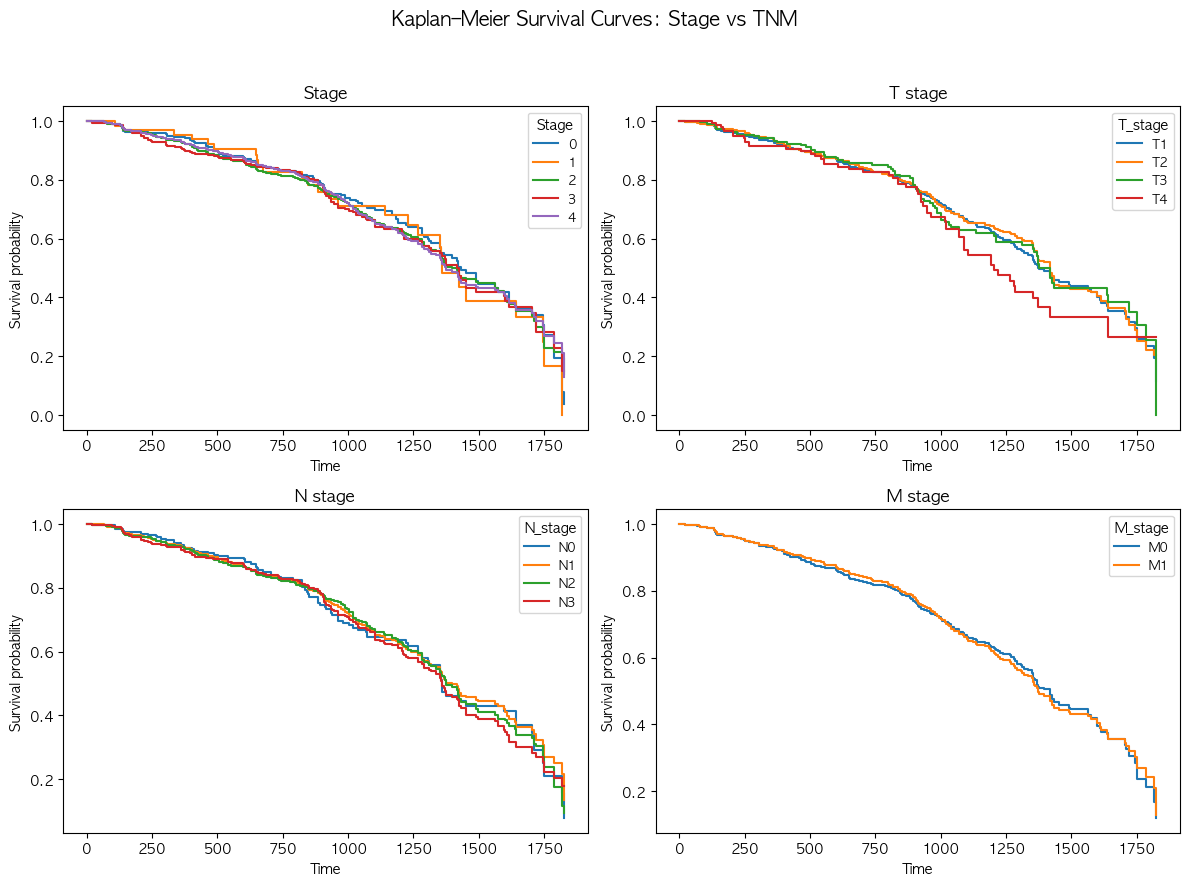

In [14]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

time_col = "Survival period"
event_col = "Death"

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

kmf = KaplanMeierFitter()

plots = [
    ("Stage",   "Stage"),
    ("T_stage", "T stage"),
    ("N_stage", "N stage"),
    ("M_stage", "M stage")
]

for ax, (col, title) in zip(axes, plots):
    # 결측 제거
    tmp = df_final[[time_col, event_col, col]].dropna()

    # category 순서 유지
    levels = (
        tmp[col].cat.categories
        if str(tmp[col].dtype) == "category"
        else sorted(tmp[col].unique())
    )

    for lv in levels:
        mask = tmp[col] == lv
        if mask.sum() < 20:
            continue  # 표본 너무 작은 그룹 제외

        kmf.fit(
            durations=tmp.loc[mask, time_col],
            event_observed=tmp.loc[mask, event_col],
            label=str(lv)
        )
        kmf.plot(ax=ax, ci_show=False)

    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("Survival probability")
    ax.legend(title=col, fontsize=9)

plt.suptitle("Kaplan–Meier Survival Curves: Stage vs TNM", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Stage_3grp counts:
Stage_3grp
4      7053
0-2    2612
3       335
Name: count, dtype: int64


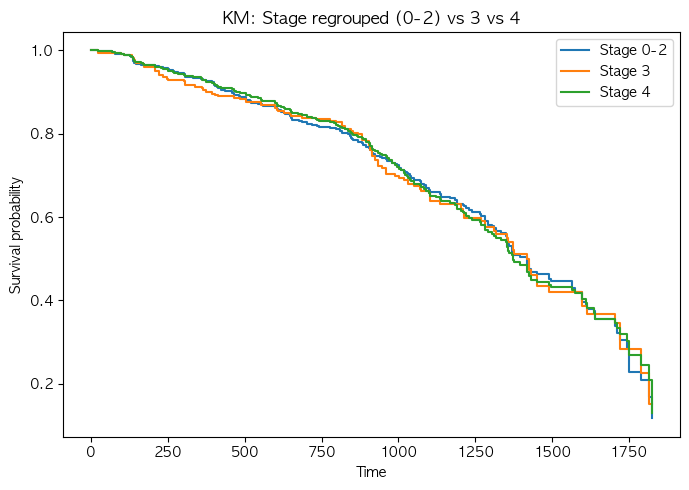


[Stage_3grp log-rank]
0.053822566122628736 0.9734475989845481

T_2grp counts:
T_2grp
T1-3    9847
T4       153
Name: count, dtype: int64


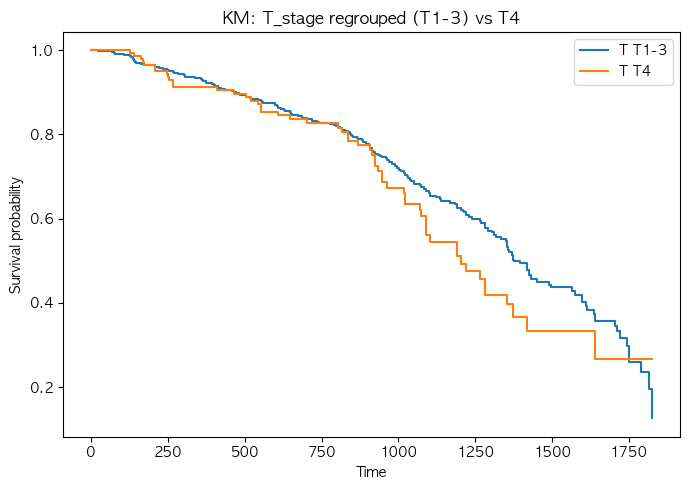


[T_2grp log-rank]
2.210815146386388 0.13704623985416775


In [15]:
# KM 곡선 상 차이가 있어보이는 stage, T-stage만 구간 나눠서 추가 확인

from lifelines.statistics import logrank_test, multivariate_logrank_test

time_col = "Survival period"
event_col = "Death"

# 1) Stage 재그룹: (0-2) / (3) / (4)
tmp_stage = df_final[[time_col, event_col, "Stage"]].dropna().copy()
tmp_stage["Stage"] = tmp_stage["Stage"].astype(str)

def stage_3grp(x):
    try:
        xi = int(float(x))
    except:
        return np.nan
    if xi <= 2:
        return "0-2"
    elif xi == 3:
        return "3"
    else:
        return "4"

tmp_stage["Stage_3grp"] = tmp_stage["Stage"].apply(stage_3grp).astype("category")
print("Stage_3grp counts:")
print(tmp_stage["Stage_3grp"].value_counts())

kmf = KaplanMeierFitter()
plt.figure(figsize=(7, 5))

for g in tmp_stage["Stage_3grp"].cat.categories:
    mask = tmp_stage["Stage_3grp"] == g
    if mask.sum() == 0:
        continue
    kmf.fit(
        durations=tmp_stage.loc[mask, time_col],
        event_observed=tmp_stage.loc[mask, event_col],
        label=f"Stage {g}"
    )
    kmf.plot(ci_show=False)

plt.title("KM: Stage regrouped (0-2) vs 3 vs 4")
plt.xlabel("Time")
plt.ylabel("Survival probability")
plt.legend()
plt.tight_layout()
plt.show()

lr_stage3 = multivariate_logrank_test(
    tmp_stage[time_col],
    tmp_stage["Stage_3grp"],
    tmp_stage[event_col]
)
print("\n[Stage_3grp log-rank]")
print(lr_stage3.test_statistic, lr_stage3.p_value)

# 2) T_stage 재그룹: (T1-3) / (T4)
tmp_T = df_final[[time_col, event_col, "T_stage"]].dropna().copy()

tmp_T["T_2grp"] = np.where(tmp_T["T_stage"].astype(str) == "T4", "T4", "T1-3")
tmp_T["T_2grp"] = tmp_T["T_2grp"].astype("category")
print("\nT_2grp counts:")
print(tmp_T["T_2grp"].value_counts())

kmf = KaplanMeierFitter()
plt.figure(figsize=(7, 5))

for g in tmp_T["T_2grp"].cat.categories:
    mask = tmp_T["T_2grp"] == g
    if mask.sum() == 0:
        continue
    kmf.fit(
        durations=tmp_T.loc[mask, time_col],
        event_observed=tmp_T.loc[mask, event_col],
        label=f"T {g}"
    )
    kmf.plot(ci_show=False)

plt.title("KM: T_stage regrouped (T1-3) vs T4")
plt.xlabel("Time")
plt.ylabel("Survival probability")
plt.legend()
plt.tight_layout()
plt.show()

# 2그룹 log-rank는 logrank_test
mask_A = tmp_T["T_2grp"] == "T1-3"
lr_T2 = logrank_test(
    tmp_T.loc[mask_A, time_col],
    tmp_T.loc[~mask_A, time_col],
    event_observed_A=tmp_T.loc[mask_A, event_col],
    event_observed_B=tmp_T.loc[~mask_A, event_col]
)
print("\n[T_2grp log-rank]")
print(lr_T2.test_statistic, lr_T2.p_value)

In [18]:
time_col = "Survival period"
event_col = "Death"

# 이미 확인한 병기 변수 제외
exclude_vars = ['Stage', 'T_stage', 'N_stage', 'M_stage']

cat_vars = [
    c for c in df_final.select_dtypes(include='category').columns
    if c not in exclude_vars
]

cat_vars

def km_logrank_summary(df, group_col):
    kmf = KaplanMeierFitter()
    tmp = df[[time_col, event_col, group_col]].dropna().copy()

    print(f"\n=== KM by {group_col} ===")

    for lv in tmp[group_col].cat.categories:
        mask = tmp[group_col] == lv
        if mask.sum() < 10:   # 너무 작은 레벨 방지
            continue

        kmf.fit(
            durations=tmp.loc[mask, time_col],
            event_observed=tmp.loc[mask, event_col],
            label=str(lv)
        )

        print(
            f"{group_col}={lv}: "
            f"n={mask.sum()}, "
            f"median={kmf.median_survival_time_}"
        )

    # log-rank
    lr = multivariate_logrank_test(
        event_durations=tmp[time_col],
        groups=tmp[group_col],
        event_observed=tmp[event_col]
    )

    print(f"[{group_col} log-rank]")
    print(lr.test_statistic, lr.p_value)

    return {
        "variable": group_col,
        "n_levels": tmp[group_col].nunique(),
        "n": tmp.shape[0],
        "events": tmp[event_col].sum(),
        "chi2": lr.test_statistic,
        "p_value": lr.p_value
    }

rows = []

for v in cat_vars:
    try:
        res = km_logrank_summary(df_final, v)
        rows.append(res)
    except Exception as e:
        print(f"{v}: ERROR → {e}")


=== KM by Menopause_status ===
Menopause_status=0: n=1236, median=1374.0
Menopause_status=1: n=8764, median=1375.0
[Menopause_status log-rank]
0.9945818083514383 0.31862511301740476

=== KM by Has_birth ===
Has_birth=0: n=1764, median=1425.0
Has_birth=1: n=8236, median=1374.0
[Has_birth log-rank]
1.5410970801084054 0.21445458084041438

=== KM by ER_clean ===
ER_clean=1: n=5009, median=1375.0
ER_clean=2: n=2879, median=1372.0
ER_clean=99: n=2112, median=1417.0
[ER_clean log-rank]
0.23849359191911193 0.8875887204190435

=== KM by PR_clean ===
PR_clean=1: n=4515, median=1374.0
PR_clean=2: n=3514, median=1375.0
PR_clean=99: n=1971, median=1397.0
[PR_clean log-rank]
0.3151998116351873 0.8541914706481648

=== KM by AR_clean ===
AR_clean=1.0: n=6731, median=1374.0
AR_clean=2.0: n=1700, median=1417.0
AR_clean=99.0: n=1569, median=1375.0
[AR_clean log-rank]
0.07159159765120429 0.9648372942771359

=== KM by Hormone_status ===
Hormone_status=1_1: n=2244, median=1372.0
Hormone_status=1_2: n=1795,

In [20]:
km_results = pd.DataFrame(rows).sort_values("p_value")
km_results

,variable,n_levels,n,events,chi2,p_value
6,Diagnosis,6,10000,3476,8.456402,0.132812
1,Has_birth,2,10000,3476,1.541097,0.214455
7,BRCA_status,4,10000,3476,4.186513,0.242016
0,Menopause_status,2,10000,3476,0.994582,0.318625
11,treat,16,10000,3476,15.514033,0.415063
8,BMI_group,4,10000,3476,1.893987,0.594699
9,AGE_group,3,10000,3476,0.740985,0.690394
3,PR_clean,3,10000,3476,0.315200,0.854191
2,ER_clean,3,10000,3476,0.238494,0.887589
10,Surgery_type,4,10000,3476,0.390683,0.942160


=== 후보 변수 요약 (p<0.20 여부 표시) ===
      variable  n_levels      chi2   p_value  pass_alpha
6    Diagnosis         6  8.456402  0.132812        True
1    Has_birth         2  1.541097  0.214455       False
7  BRCA_status         4  4.186513  0.242016       False


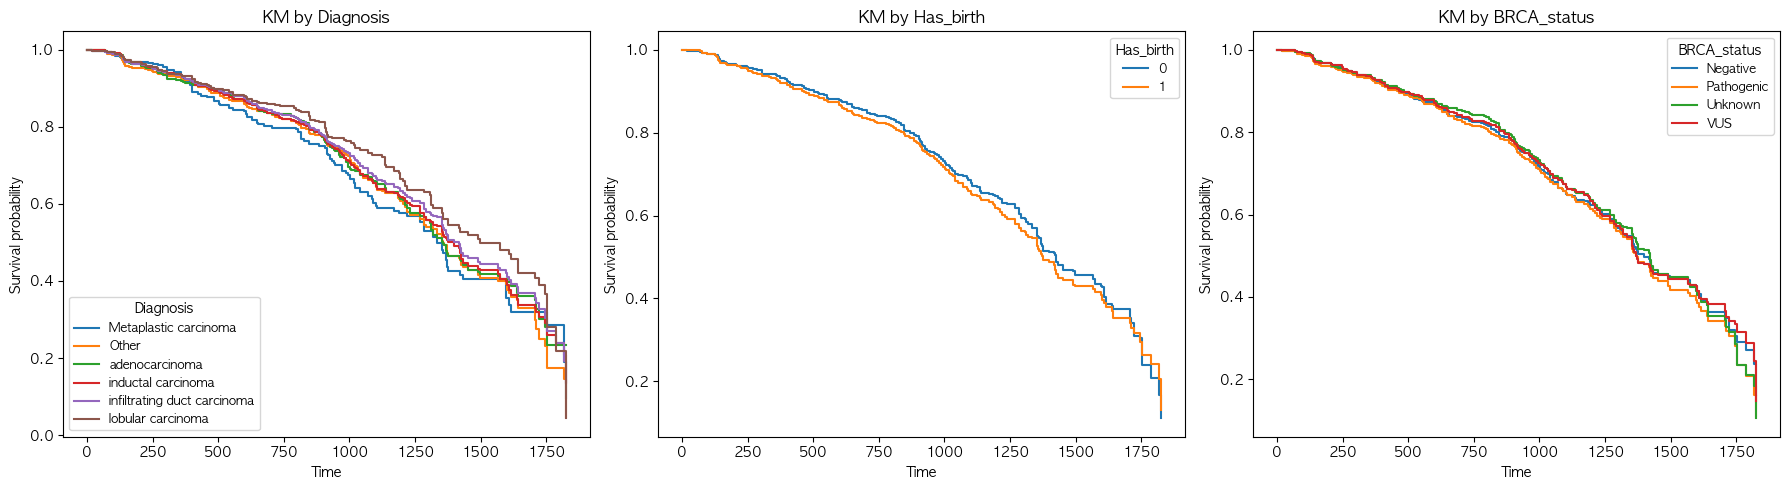


=== 추가 확인 log-rank 결과 ===
      variable      chi2   p_value  pass_alpha
0    Diagnosis  8.456402  0.132812        True
1    Has_birth  1.541097  0.214455       False
2  BRCA_status  4.186513  0.242016       False


In [22]:
# 유의확률 20%로 완화해서 추가 확인

alpha = 0.20  

candidates = ["Diagnosis", "Has_birth", "BRCA_status"]

if "km_results" in globals():
    cand_tbl = (
        km_results[km_results["variable"].isin(candidates)]
        .sort_values("p_value")
        .copy()
    )
    cand_tbl["pass_alpha"] = cand_tbl["p_value"] < alpha
    print("=== 후보 변수 요약 (p<0.20 여부 표시) ===")
    print(cand_tbl[["variable", "n_levels", "chi2", "p_value", "pass_alpha"]])

def plot_km(df, group_col, ax, min_n=20):
    kmf = KaplanMeierFitter()
    tmp = df[[time_col, event_col, group_col]].dropna().copy()

    levels = (
        list(tmp[group_col].cat.categories)
        if str(tmp[group_col].dtype) == "category"
        else sorted(tmp[group_col].unique())
    )

    for lv in levels:
        mask = tmp[group_col] == lv
        if mask.sum() < min_n:
            continue
        kmf.fit(
            durations=tmp.loc[mask, time_col],
            event_observed=tmp.loc[mask, event_col],
            label=str(lv)
        )
        kmf.plot(ax=ax, ci_show=False)

    # log-rank (버전 호환: 위치 인자)
    lr = multivariate_logrank_test(tmp[time_col], tmp[group_col], tmp[event_col])

    ax.set_title(f"KM by {group_col}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Survival probability")
    ax.legend(title=group_col, fontsize=9)

    return {"variable": group_col, "chi2": lr.test_statistic, "p_value": lr.p_value}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

lr_out = []
for ax, v in zip(axes, candidates):
    lr_out.append(plot_km(df_final, v, ax=ax, min_n=20))

plt.tight_layout()
plt.show()

print("\n=== 추가 확인 log-rank 결과 ===")
out_df = pd.DataFrame(lr_out).sort_values("p_value")
out_df["pass_alpha"] = out_df["p_value"] < alpha
print(out_df)

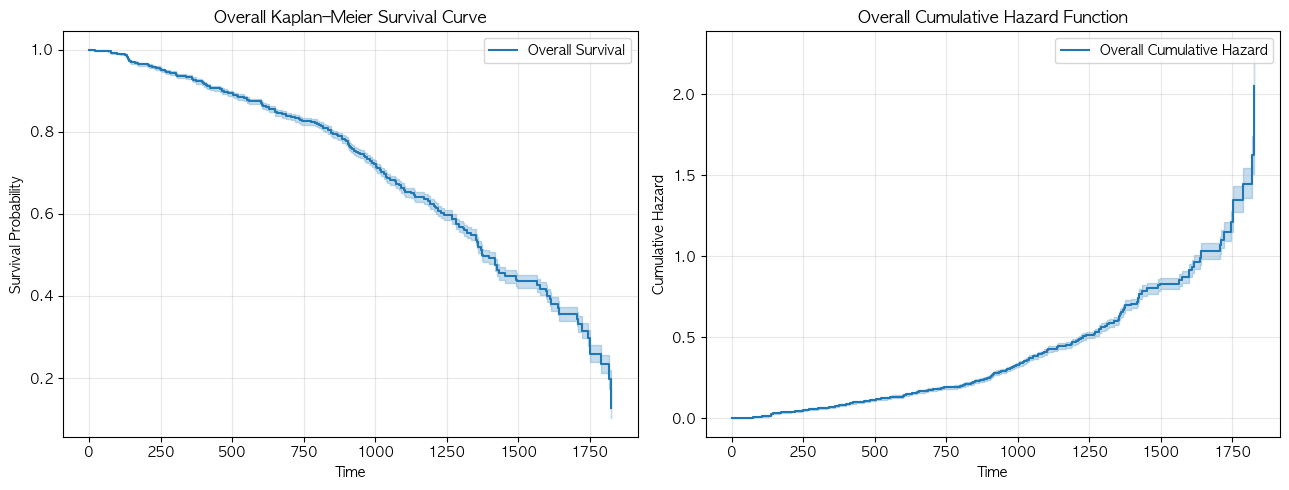

Median survival time (KM): 1375.0


In [24]:
from lifelines import KaplanMeierFitter, NelsonAalenFitter

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1) Overall KM survival curve
kmf = KaplanMeierFitter()
kmf.fit(
    durations=df_final[time_col],
    event_observed=df_final[event_col],
    label="Overall Survival"
)
kmf.plot(ax=axes[0], ci_show=True)
axes[0].set_title("Overall Kaplan–Meier Survival Curve")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Survival Probability")
axes[0].grid(alpha=0.3)

# 2) Overall cumulative hazard (Nelson–Aalen)
naf = NelsonAalenFitter()
naf.fit(
    durations=df_final[time_col],
    event_observed=df_final[event_col],
    label="Overall Cumulative Hazard"
)
naf.plot(ax=axes[1], ci_show=True)
axes[1].set_title("Overall Cumulative Hazard Function")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Cumulative Hazard")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Median survival time (KM):", kmf.median_survival_time_)

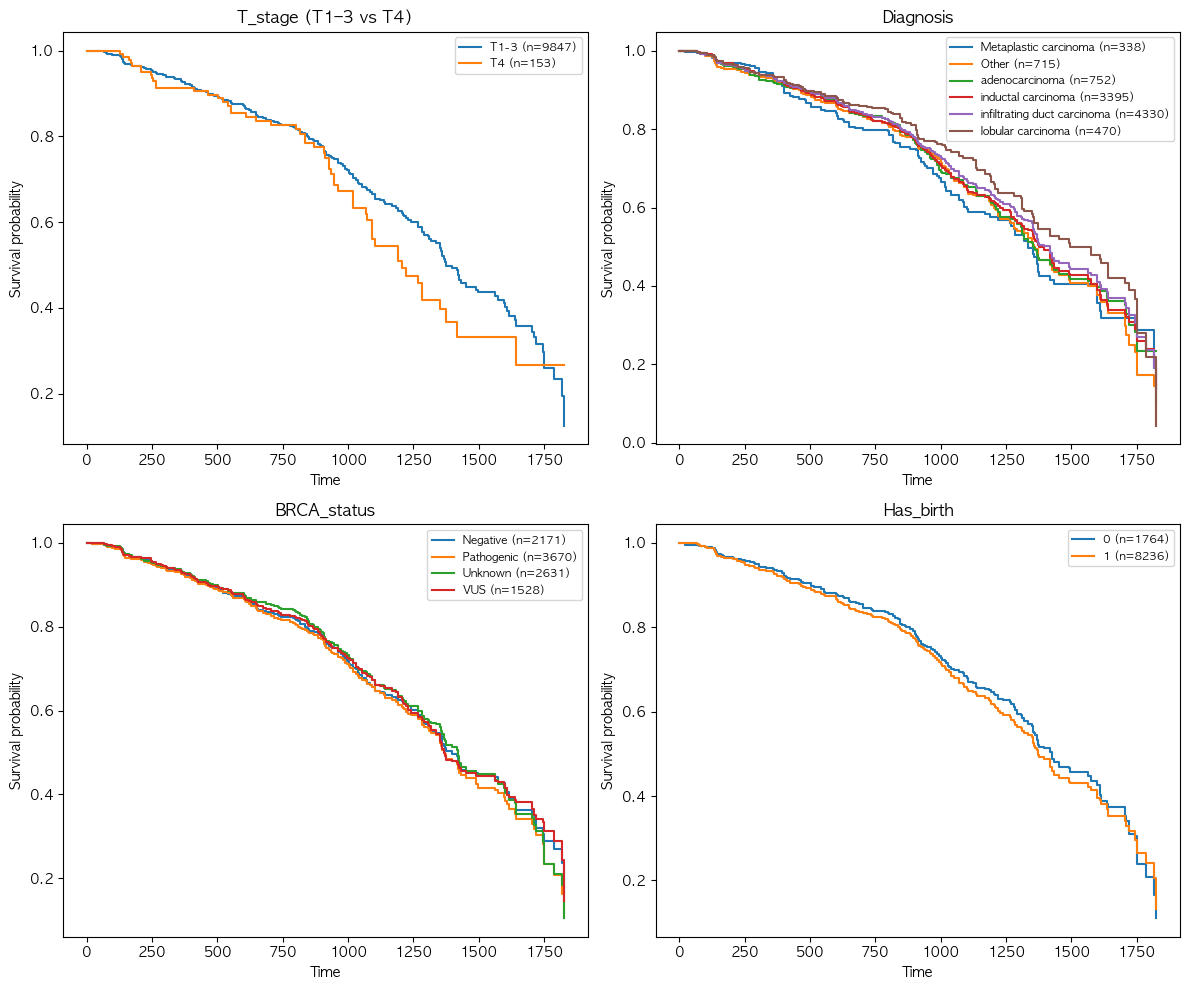

In [26]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

time_col = "Survival period"
event_col = "Death"

kmf = KaplanMeierFitter()

def plot_km(df, group_col, ax, min_n=20, title=None):
    tmp = df[[time_col, event_col, group_col]].dropna().copy()

    # 범주 레벨 순서 유지
    if str(tmp[group_col].dtype) == "category":
        levels = tmp[group_col].cat.categories
    else:
        levels = sorted(tmp[group_col].unique())

    for lv in levels:
        mask = tmp[group_col] == lv
        if mask.sum() < min_n:
            continue

        kmf.fit(
            durations=tmp.loc[mask, time_col],
            event_observed=tmp.loc[mask, event_col],
            label=f"{lv} (n={mask.sum()})"
        )
        kmf.plot_survival_function(ax=ax, ci_show=False)

    ax.set_title(title if title else f"KM by {group_col}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Survival probability")
    ax.legend(fontsize=8)


# 4분할 KM plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1) T-stage (T1-3 vs T4)
tmp_T = df_final[[time_col, event_col, "T_stage"]].dropna().copy()
tmp_T["T_2grp"] = tmp_T["T_stage"].astype(str).replace(
    {"T1": "T1-3", "T2": "T1-3", "T3": "T1-3", "T4": "T4"}
).astype("category")

plot_km(tmp_T, "T_2grp", axes[0, 0], title="T_stage (T1–3 vs T4)")

# 2) Diagnosis
plot_km(df_final, "Diagnosis", axes[0, 1], title="Diagnosis")

# 3) BRCA_status
plot_km(df_final, "BRCA_status", axes[1, 0], title="BRCA_status")

# 4) Has_birth
plot_km(df_final, "Has_birth", axes[1, 1], title="Has_birth")

plt.tight_layout()
plt.show()

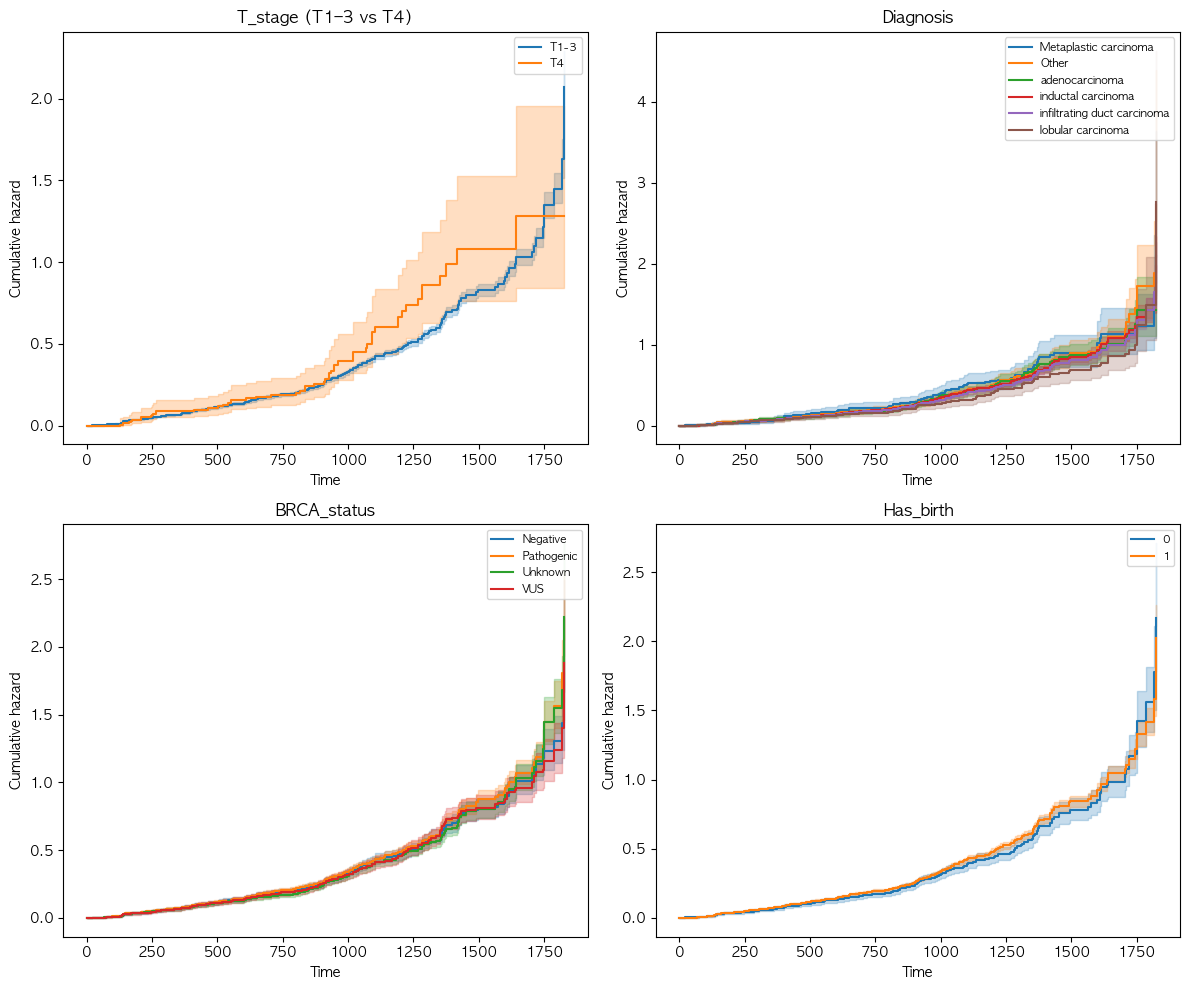

In [28]:
time_col = "Survival period"
event_col = "Death"

naf = NelsonAalenFitter()

def plot_na(df, group_col, ax, min_n=20, title=None):
    tmp = df[[time_col, event_col, group_col]].dropna().copy()

    if str(tmp[group_col].dtype) == "category":
        levels = tmp[group_col].cat.categories
    else:
        levels = sorted(tmp[group_col].unique())

    for lv in levels:
        mask = tmp[group_col] == lv
        if mask.sum() < min_n:
            continue

        naf.fit(
            durations=tmp.loc[mask, time_col],
            event_observed=tmp.loc[mask, event_col],
            label=str(lv)
        )
        naf.plot(ax=ax)

    ax.set_title(title if title else f"NA by {group_col}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Cumulative hazard")
    ax.legend(fontsize=8)


# 4분할 NA plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1) T-stage (T1-3 vs T4)
tmp_T = df_final[[time_col, event_col, "T_stage"]].dropna().copy()
tmp_T["T_2grp"] = tmp_T["T_stage"].astype(str).replace(
    {"T1":"T1-3","T2":"T1-3","T3":"T1-3","T4":"T4"}
).astype("category")

plot_na(tmp_T, "T_2grp", axes[0, 0], title="T_stage (T1–3 vs T4)")

# 2) Diagnosis
plot_na(df_final, "Diagnosis", axes[0, 1], title="Diagnosis")

# 3) BRCA_status
plot_na(df_final, "BRCA_status", axes[1, 0], title="BRCA_status")

# 4) Has_birth
plot_na(df_final, "Has_birth", axes[1, 1], title="Has_birth")

plt.tight_layout()
plt.show()

# COX생존비례위험함수

In [39]:
df_u = df_final.copy()
df_u = df_u.rename(columns=lambda c: c.replace(" ", "_"))

time_col_u = time_col.replace(" ", "_")
event_col_u = event_col.replace(" ", "_")

binary_as_cat = [
    "Has_birth",
    "Menopause_status",
    "M_stage",           
    "Chemotherapy",
    "Hormone_therapy",
    "Radiation_Therapy",
]

binary_as_cat = [c for c in binary_as_cat if c in df_u.columns]
for c in binary_as_cat:
    df_u[c] = df_u[c].astype("category")
    
# 단변량 Cox 함수
def univariate_cox(df, var):
    tmp = df[[time_col_u, event_col_u, var]].dropna().copy()

    if tmp[var].nunique(dropna=True) < 2:
        return None

    cph = CoxPHFitter()
    cph.fit(
        tmp,
        duration_col=time_col_u,
        event_col=event_col_u,
        formula=var
    )

    s = cph.summary.reset_index()  

    out = {
        "variable": var,
        "variable_display": var.replace("_", " "),
        "type": "categorical" if str(df[var].dtype) == "category" else "continuous",
        "n": tmp.shape[0],
        "events": int(tmp[event_col_u].sum()),
        "c_index": float(cph.concordance_index_),
        "AIC_partial": float(cph.AIC_partial_)
    }

    # 범주형(더미 여러 줄)
    if s.shape[0] > 1:
        out["n_levels"] = int(tmp[var].nunique())
        out["min_p_value"] = float(s["p"].min())
        out["HR_range"] = f"{s['exp(coef)'].min():.3f}–{s['exp(coef)'].max():.3f}"
    else:
        out["HR"] = float(s.loc[0, "exp(coef)"])
        out["CI_lower"] = float(s.loc[0, "exp(coef) lower 95%"])
        out["CI_upper"] = float(s.loc[0, "exp(coef) upper 95%"])
        out["p_value"] = float(s.loc[0, "p"])

    return out

In [41]:
# 단변량 Cox 전체 실행
covariates = [c for c in df_u.columns if c not in [time_col_u, event_col_u]]

rows = []
errors = []

for v in covariates:
    try:
        res = univariate_cox(df_u, v)
        if res is not None:
            rows.append(res)
    except Exception as e:
        errors.append((v, str(e)))

uni_cox = pd.DataFrame(rows)


uni_cox["p_for_sort"] = uni_cox["p_value"].fillna(uni_cox.get("min_p_value"))
uni_cox = (
    uni_cox.sort_values(["p_for_sort", "c_index"], ascending=[True, False])
           .drop(columns=["p_for_sort"])
           .reset_index(drop=True)
)

print(f"단변량 Cox 완료: {uni_cox.shape[0]}개 변수")
if errors:
    print(f"에러 변수: {len(errors)}개 (상위 10개만 표시)")
    for v, msg in errors[:10]:
        print(f"- {v}: {msg}")

uni_cox

단변량 Cox 완료: 26개 변수


,variable,variable_display,type,n,events,c_index,AIC_partial,HR,CI_lower,CI_upper,p_value,n_levels,min_p_value,HR_range
0,Diagnosis,Diagnosis,categorical,10000,3476,0.512481,57207.971773,NaN,NaN,NaN,NaN,6.0,0.029403,0.770–0.956
1,treat,treat,categorical,10000,3476,0.518119,57220.687649,NaN,NaN,NaN,NaN,16.0,0.073696,0.825–1.106
2,T_stage,T stage,categorical,10000,3476,0.503597,57209.647359,NaN,NaN,NaN,NaN,4.0,0.158557,0.961–1.212
3,BMI,BMI,continuous,10000,3476,0.506644,57206.414769,1.004491,0.998091,1.010933,0.169461,NaN,NaN,NaN
4,BRCA_status,BRCA status,categorical,10000,3476,0.509743,57208.122634,NaN,NaN,NaN,NaN,4.0,0.172422,0.982–1.065
5,Has_birth,Has birth,categorical,10000,3476,0.506396,57206.791099,1.055838,0.967526,1.152211,0.222772,NaN,NaN,NaN
6,Hormone_status,Hormone status,categorical,10000,3476,0.510116,57220.106757,NaN,NaN,NaN,NaN,9.0,0.279315,0.931–1.024
7,Menopause_status,Menopause status,categorical,10000,3476,0.501609,57207.293323,0.950195,0.860276,1.049513,0.313836,NaN,NaN,NaN
8,BMI_group,BMI group,categorical,10000,3476,0.506166,57210.386344,NaN,NaN,NaN,NaN,4.0,0.375064,0.966–1.036
9,Age_of_Menarch,Age of Menarch,continuous,10000,3476,0.503912,57207.660454,1.003716,0.994616,1.012899,0.424758,NaN,NaN,NaN


In [45]:
from lifelines import CoxPHFitter

def _extract_level_name(covariate, var):
    s = str(covariate)
    prefix = f"C({var})[T."
    if s.startswith(prefix) and s.endswith("]"):
        return s[len(prefix):-1]
    return s

def univariate_cox_longtable(df, var, time_col, event_col, var_label=None):
    """
    단변량 Cox 결과를 '논문 표 형태(long format)'로 반환.
    - 범주형: 기준군(ref) 포함 + 모든 레벨별 coef/HR/SE/Z/p/CI
    - 연속형: 1행 coef/HR/SE/Z/p/CI
    """
    var_label = var_label or var
    tmp = df[[time_col, event_col, var]].dropna().copy()

    # 레벨이 1개면 모델 불가
    if tmp[var].nunique(dropna=True) < 2:
        return None

    # 범주형 여부
    is_cat = (str(tmp[var].dtype) == "category") or (tmp[var].dtype == "object")

    cph = CoxPHFitter()

    if is_cat:
        tmp[var] = tmp[var].astype("category")
        levels = tmp[var].cat.categories.tolist()

        # 범주형은 C()로 명시
        cph.fit(tmp, duration_col=time_col, event_col=event_col, formula=f"C({var})")
        s = cph.summary.reset_index().rename(columns={"index": "covariate"})

        # summary에 포함된(추정된) 레벨 추출
        est_levels = [_extract_level_name(cv, var) for cv in s["covariate"].tolist()]
        # 기준군은 levels 중 est_levels에 없는 것
        ref_level = [lv for lv in levels if lv not in est_levels]
        ref_level = ref_level[0] if len(ref_level) == 1 else levels[0]  # 안전장치

        rows = []
        # 기준군(ref) 행 추가
        rows.append({
            "변수": var_label,
            "수준": f"{ref_level} (ref)",
            "coef": 0.0,
            "HR": 1.0,
            "SE": np.nan,
            "Z": np.nan,
            "p-값": np.nan,
            "신뢰구간 하한": np.nan,
            "신뢰구간 상한": np.nan,
            "n": int(tmp.shape[0]),
            "events": int(tmp[event_col].sum())
        })

        # 나머지 레벨 행들
        for _, r in s.iterrows():
            lv = _extract_level_name(r["covariate"], var)
            rows.append({
                "변수": var_label,
                "수준": lv,
                "coef": float(r["coef"]),
                "HR": float(r["exp(coef)"]),
                "SE": float(r["se(coef)"]),
                "Z": float(r["z"]),
                "p-값": float(r["p"]),
                "신뢰구간 하한": float(r["exp(coef) lower 95%"]),
                "신뢰구간 상한": float(r["exp(coef) upper 95%"]),
                "n": int(tmp.shape[0]),
                "events": int(tmp[event_col].sum())
            })

        out = pd.DataFrame(rows)

        # 원래 category 순서로 정렬(ref 포함)
        order = [f"{ref_level} (ref)"] + [lv for lv in levels if lv != ref_level]
        # out["수준"]에 실제 levels 텍스트가 들어가 있으므로, ref만 따로 맨 위 고정
        out["__is_ref"] = out["수준"].str.endswith("(ref)")
        out = out.sort_values(["변수", "__is_ref"], ascending=[True, False]).drop(columns="__is_ref")

    else:
        # 연속형
        tmp[var] = pd.to_numeric(tmp[var], errors="coerce")
        tmp = tmp.dropna(subset=[var])

        if tmp[var].nunique(dropna=True) < 2:
            return None

        cph.fit(tmp, duration_col=time_col, event_col=event_col, formula=var)
        r = cph.summary.iloc[0]

        out = pd.DataFrame([{
            "변수": var_label,
            "수준": "-",  # 연속형은 수준 없음
            "coef": float(r["coef"]),
            "HR": float(r["exp(coef)"]),
            "SE": float(r["se(coef)"]),
            "Z": float(r["z"]),
            "p-값": float(r["p"]),
            "신뢰구간 하한": float(r["exp(coef) lower 95%"]),
            "신뢰구간 상한": float(r["exp(coef) upper 95%"]),
            "n": int(tmp.shape[0]),
            "events": int(tmp[event_col].sum())
        }])

    num_cols = ["coef", "HR", "SE", "Z", "p-값", "신뢰구간 하한", "신뢰구간 상한"]
    for c in num_cols:
        out[c] = pd.to_numeric(out[c], errors="coerce").round(4)

    return out


var_list = [
    ("Diagnosis", "조직학적 진단 (Diagnosis)"),
    ("T_stage", "T 병기 (T-stage)"),
    ("BRCA_status", "BRCA 유전자 상태 (BRCA status)"),
    ("BMI", "BMI (연속형)"),
]

tables = []
for v, lab in var_list:
    if v in df_u.columns:
        t = univariate_cox_longtable(df_u, v, time_col_u, event_col_u, var_label=lab)
        if t is not None:
            tables.append(t)

table_32 = pd.concat(tables, ignore_index=True)

table_32 = table_32[[
    "변수", "수준", "coef", "HR", "SE", "Z", "p-값", "신뢰구간 하한", "신뢰구간 상한"
]]

table_32

,변수,수준,coef,HR,SE,Z,p-값,신뢰구간 하한,신뢰구간 상한
0,조직학적 진단 (Diagnosis),Metaplastic carcinoma (ref),0.0000,1.0000,NaN,NaN,NaN,NaN,NaN
1,조직학적 진단 (Diagnosis),Other,-0.0451,0.9559,0.1074,-0.4194,0.6749,0.7744,1.1800
2,조직학적 진단 (Diagnosis),adenocarcinoma,-0.0999,0.9050,0.1070,-0.9331,0.3508,0.7337,1.1162
3,조직학적 진단 (Diagnosis),inductal carcinoma,-0.1113,0.8947,0.0924,-1.2046,0.2284,0.7466,1.0723
4,조직학적 진단 (Diagnosis),infiltrating duct carcinoma,-0.1567,0.8549,0.0915,-1.7131,0.0867,0.7146,1.0228
5,조직학적 진단 (Diagnosis),lobular carcinoma,-0.2618,0.7696,0.1202,-2.1780,0.0294,0.6081,0.9741
6,T 병기 (T-stage),T1 (ref),0.0000,1.0000,NaN,NaN,NaN,NaN,NaN
7,T 병기 (T-stage),T2,-0.0399,0.9608,0.0521,-0.7669,0.4432,0.8676,1.0641
8,T 병기 (T-stage),T3,-0.0342,0.9664,0.1133,-0.3018,0.7628,0.7739,1.2068
9,T 병기 (T-stage),T4,0.1920,1.2116,0.1361,1.4099,0.1586,0.9279,1.5821


In [37]:
# Null Cox(공변량 없는 콕스)

time_col = "Survival period"
event_col = "Death"

df_null = df_final[[time_col, event_col]].copy()
df_null = df_null[df_null[time_col] > 0]

cph_null = CoxPHFitter()
cph_null.fit(df_null, duration_col=time_col, event_col=event_col)

print("Null Cox n:", df_null.shape[0], "events:", int(df_null[event_col].sum()))
print("Null Cox C-index:", cph_null.concordance_index_)
print("Null Cox AIC_partial:", cph_null.AIC_partial_)

Null Cox n: 10000 events: 3476
Null Cox C-index: 0.5
Null Cox AIC_partial: 57206.295021751146


In [39]:
# Full Cox
cox_vars = [
    "Stage",
    "AGE", "BMI",
    "Has_birth", "Menopause_status",
    "Diagnosis",
    "ER_clean", "PR_clean", "AR_clean",
    "BRCA_status",
    "Smoke",
    "treat",
]
cox_vars = [v for v in cox_vars if v in df_final.columns]

df_cox = df_final[[time_col, event_col] + cox_vars].copy()
df_cox = df_cox.dropna()

print("Cox sample size:", df_cox.shape[0])
print("Events:", int(df_cox[event_col].sum()))

cat_for_cox = [
    "Stage", "Diagnosis",
    "ER_clean", "PR_clean", "AR_clean",
    "BRCA_status", "treat",
    "Has_birth", "Menopause_status", "Smoke",
]
cat_for_cox = [c for c in cat_for_cox if c in df_cox.columns]

cont_for_cox = [c for c in cox_vars if c not in cat_for_cox]

formula_terms = [f"C({c})" for c in cat_for_cox] + cont_for_cox
formula = " + ".join(formula_terms)

print("\n[formula]")
print(formula)

cph_full = CoxPHFitter()
cph_full.fit(df_cox, duration_col=time_col, event_col=event_col, formula=formula)

cph_full.print_summary()
print("\nFull Cox C-index:", cph_full.concordance_index_)
print("Full Cox AIC_partial:", cph_full.AIC_partial_)

Cox sample size: 10000
Events: 3476

[formula]
C(Stage) + C(Diagnosis) + C(ER_clean) + C(PR_clean) + C(AR_clean) + C(BRCA_status) + C(treat) + C(Has_birth) + C(Menopause_status) + C(Smoke) + AGE + BMI


<lifelines.CoxPHFitter: fitted with 10000 total observations, 6524 right-censored observations>
             duration col = 'Survival period'
                event col = 'Death'
      baseline estimation = breslow
   number of observations = 10000
number of events observed = 3476
   partial log-likelihood = -28585.44
         time fit was run = 2025-12-17 09:18:03 UTC

---
                                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                    
C(Stage)[T.1]                                0.06      1.06      0.21           -0.36            0.48                0.70                1.61
C(Stage)[T.2]                                0.04      1.04      0.10           -0.15            0.24                0.86                1.26
C(Stage)[T.3]                                0.05      1.05      0.13           -0.21            0.30                0.81                1.34
C(Stage)[T.4]                                0.03      1.03      0.09           -0.15            0.21                0.86                1.24
C(Diagnosis)[T.Other]                       -0.05      0.95      0.11           -0.26            0.16                0.77                1.18
C(Diagnosis)[T.adenocarcinoma]              -0.10      0.91      0.11           -0.31            0.11                0.73                1.12
C(Diagnosis)[T.inductal carcinoma]          -0.12      0.89      0.09           -0.30            0.07                0.74                1.07
C(Diagnosis)[T.infiltrating duct carcinoma] -0.16      0.85      0.09           -0.34            0.02                0.71                1.02
C(Diagnosis)[T.lobular carcinoma]           -0.27      0.76      0.12           -0.51           -0.03                0.60                0.97
C(ER_clean)[T.2]                            -0.02      0.98      0.04           -0.10            0.06                0.91                1.06
C(ER_clean)[T.99]                            0.00      1.00      0.04           -0.08            0.09                0.92                1.09
C(PR_clean)[T.2]                            -0.02      0.98      0.04           -0.09            0.06                0.91                1.06
C(PR_clean)[T.99]                           -0.02      0.98      0.05           -0.11            0.07                0.89                1.07
C(AR_clean)[T.2.0]                           0.01      1.01      0.05           -0.08            0.10                0.92                1.11
C(AR_clean)[T.99.0]                          0.01      1.01      0.05           -0.09            0.10                0.92                1.11
C(BRCA_status)[T.Pathogenic]                 0.07      1.07      0.05           -0.02            0.16                0.98                1.17
C(BRCA_status)[T.Unknown]                   -0.01      0.99      0.05           -0.11            0.09                0.90                1.09
C(BRCA_status)[T.VUS]                       -0.02      0.98      0.06           -0.13            0.09                0.88                1.09
C(treat)[T.Chemo+Hormone]                   -0.19      0.83      0.10           -0.39            0.02                0.68                1.02
C(treat)[T.Chemo+Radio]                     -0.11      0.90      0.10           -0.31            0.09                0.74                1.10
C(treat)[T.Chemo+Radio+Hormone]              0.04      1.04      0.10           -0.15            0.23                0.86                1.26
C(treat)[T.Hormone]                         -0.12      0.89      0.12           -0.35            0.11                0.71                1.12
C(treat)[T.None]                             0.10      1.10      0.12           -0.14            0.33                0.87                1.39
C(treat)[T.Radio]                           -0.01      0.99      0.12     


Full Cox C-index: 0.5282807659422072
Full Cox AIC_partial: 57248.87776231367


In [40]:
# 참고자료 - stage 대신 T/M/N병기로 다시 한번 풀콕스

cox_vars_tnm = [
    # 병기 (TNM)
    "T_stage",
    "N_stage",
    "M_stage",

    # 인구학 / 생식
    "AGE",
    "BMI",
    "Has_birth",
    "Menopause_status",

    # 조직학
    "Diagnosis",

    # 호르몬 수용체
    "ER_clean",
    "PR_clean",
    "AR_clean",

    # 유전자
    "BRCA_status",

    # 생활습관
    "Smoke",

    # 치료
    "treat"
]

cox_vars_tnm = [v for v in cox_vars_tnm if v in df_final.columns]

df_cox_tnm = df_final[[time_col, event_col] + cox_vars_tnm].copy()
df_cox_tnm = df_cox_tnm.dropna()

print("Cox (TNM) sample size:", df_cox_tnm.shape[0])
print("Events:", int(df_cox_tnm[event_col].sum()))


cat_for_cox_tnm = [
    "T_stage", "N_stage", "M_stage",
    "Diagnosis",
    "ER_clean", "PR_clean", "AR_clean",
    "BRCA_status",
    "treat",
    "Has_birth", "Menopause_status", "Smoke",
]
cat_for_cox_tnm = [c for c in cat_for_cox_tnm if c in df_cox_tnm.columns]

cont_for_cox_tnm = [c for c in cox_vars_tnm if c not in cat_for_cox_tnm]

formula_terms_tnm = [f"C({c})" for c in cat_for_cox_tnm] + cont_for_cox_tnm
formula_tnm = " + ".join(formula_terms_tnm)

print("\n[formula - TNM model]")
print(formula_tnm)


cph_tnm = CoxPHFitter()
cph_tnm.fit(
    df_cox_tnm,
    duration_col=time_col,
    event_col=event_col,
    formula=formula_tnm
)


cph_tnm.print_summary()

print("\nTNM Cox C-index:", cph_tnm.concordance_index_)
print("TNM Cox AIC_partial:", cph_tnm.AIC_partial_)

Cox (TNM) sample size: 10000
Events: 3476

[formula - TNM model]
C(T_stage) + C(N_stage) + C(M_stage) + C(Diagnosis) + C(ER_clean) + C(PR_clean) + C(AR_clean) + C(BRCA_status) + C(treat) + C(Has_birth) + C(Menopause_status) + C(Smoke) + AGE + BMI


<lifelines.CoxPHFitter: fitted with 10000 total observations, 6524 right-censored observations>
             duration col = 'Survival period'
                event col = 'Death'
      baseline estimation = breslow
   number of observations = 10000
number of events observed = 3476
   partial log-likelihood = -28582.90
         time fit was run = 2025-12-17 09:18:03 UTC

---
                                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                    
C(T_stage)[T.T2]                            -0.04      0.96      0.05           -0.15            0.06                0.86                1.06
C(T_stage)[T.T3]                            -0.03      0.97      0.11           -0.25            0.19                0.78                1.21
C(T_stage)[T.T4]                             0.19      1.21      0.14           -0.07            0.46                0.93                1.59
C(N_stage)[T.N1]                            -0.06      0.94      0.10           -0.26            0.15                0.77                1.16
C(N_stage)[T.N2]                            -0.01      0.99      0.11           -0.23            0.20                0.79                1.22
C(N_stage)[T.N3]                             0.03      1.03      0.12           -0.20            0.26                0.82                1.30
C(M_stage)[T.M1]                            -0.00      1.00      0.04           -0.08            0.07                0.93                1.07
C(Diagnosis)[T.Other]                       -0.05      0.95      0.11           -0.26            0.16                0.77                1.17
C(Diagnosis)[T.adenocarcinoma]              -0.10      0.90      0.11           -0.31            0.11                0.73                1.11
C(Diagnosis)[T.inductal carcinoma]          -0.12      0.89      0.09           -0.30            0.06                0.74                1.06
C(Diagnosis)[T.infiltrating duct carcinoma] -0.17      0.85      0.09           -0.35            0.01                0.71                1.01
C(Diagnosis)[T.lobular carcinoma]           -0.28      0.76      0.12           -0.51           -0.04                0.60                0.96
C(ER_clean)[T.2]                            -0.02      0.98      0.04           -0.10            0.06                0.91                1.06
C(ER_clean)[T.99]                            0.00      1.00      0.04           -0.08            0.09                0.92                1.09
C(PR_clean)[T.2]                            -0.02      0.98      0.04           -0.09            0.06                0.91                1.06
C(PR_clean)[T.99]                           -0.02      0.98      0.05           -0.11            0.07                0.89                1.07
C(AR_clean)[T.2.0]                           0.01      1.01      0.05           -0.08            0.10                0.92                1.10
C(AR_clean)[T.99.0]                          0.01      1.01      0.05           -0.09            0.10                0.92                1.11
C(BRCA_status)[T.Pathogenic]                 0.07      1.07      0.05           -0.02            0.16                0.98                1.17
C(BRCA_status)[T.Unknown]                   -0.01      0.99      0.05           -0.11            0.09                0.90                1.09
C(BRCA_status)[T.VUS]                       -0.02      0.98      0.06           -0.13            0.09                0.87                1.09
C(treat)[T.Chemo+Hormone]                   -0.19      0.83      0.10           -0.39            0.02                0.68                1.02
C(treat)[T.Chemo+Radio]                     -0.11      0.90      0.10           -0.31            0.09                0.74                1.10
C(treat)[T.Chemo+Radio+Hormone]              0.05      1.05      0.10     


TNM Cox C-index: 0.5301027702031572
TNM Cox AIC_partial: 57249.792580075824


In [41]:
# 변수 선택 - 후진제거법
def backward_elimination_aic(
    df,
    time_col="Survival period",
    event_col="Death",
    covariates=None,
    categorical=None,
    penalizer=0.0,
    l1_ratio=0.0,
    min_vars=1,
    max_steps=200,
    verbose=True
):
    """
    AIC_partial 기준 후진제거(backward elimination).
    - categorical에 들어간 변수는 formula에서 C(var)로 처리
    - 각 step에서 '변수 1개 제거' 후보들을 모두 돌려보고 AIC가 가장 감소하는 제거를 채택
    - 더 이상 AIC가 감소하지 않으면 종료

    Returns
    -------
    result : dict
        {
          "selected": 최종 공변량 리스트,
          "history": 단계별 로그(DataFrame),
          "final_model": 최종 CoxPHFitter,
          "final_formula": 최종 formula 문자열,
          "final_aic": 최종 AIC_partial,
          "final_cindex": 최종 concordance_index_,
          "n": 표본수,
          "events": 사건수
        }
    """
    if covariates is None:
        covariates = [c for c in df.columns if c not in [time_col, event_col]]

    covariates = [c for c in covariates if c in df.columns]
    if categorical is None:
        categorical = []

    categorical = [c for c in categorical if c in covariates]

    def build_formula(vars_):
        cat = [v for v in vars_ if v in categorical]
        cont = [v for v in vars_ if v not in categorical]
        terms = [f"C({v})" for v in cat] + cont
        return " + ".join(terms) if terms else "1"

    # 결측 제거(고정)
    use_cols = [time_col, event_col] + covariates
    df_work = df[use_cols].copy().dropna()
    n = df_work.shape[0]
    events = int(df_work[event_col].sum())

    if verbose:
        print(f"[Backward AIC] n={n}, events={events}, start_vars={len(covariates)}")

    # 시작 모형
    current_vars = covariates.copy()
    current_formula = build_formula(current_vars)

    cph = CoxPHFitter(penalizer=penalizer, l1_ratio=l1_ratio)
    cph.fit(df_work, duration_col=time_col, event_col=event_col, formula=current_formula)
    current_aic = float(cph.AIC_partial_)
    current_cindex = float(cph.concordance_index_)

    history = [{
        "step": 0,
        "action": "start",
        "dropped": None,
        "n_vars": len(current_vars),
        "AIC_partial": current_aic,
        "c_index": current_cindex,
        "formula": current_formula
    }]

    # 반복
    step = 0
    while step < max_steps and len(current_vars) > min_vars:
        step += 1

        best_aic = current_aic
        best_drop = None
        best_model = None
        best_formula = None
        best_cindex = None

        # 변수 1개씩 제거해보며 AIC 개선 여부 평가
        for drop_var in current_vars:
            trial_vars = [v for v in current_vars if v != drop_var]
            trial_formula = build_formula(trial_vars)

            try:
                m = CoxPHFitter(penalizer=penalizer, l1_ratio=l1_ratio)
                m.fit(df_work, duration_col=time_col, event_col=event_col, formula=trial_formula)
                aic = float(m.AIC_partial_)
                if aic < best_aic - 1e-8:  # 아주 미세한 개선은 무시
                    best_aic = aic
                    best_drop = drop_var
                    best_model = m
                    best_formula = trial_formula
                    best_cindex = float(m.concordance_index_)
            except Exception:
                # 특정 제거 조합에서 수렴/행렬 문제 등 발생 시 스킵
                continue

        # 개선 없으면 종료
        if best_drop is None:
            if verbose:
                print(f"[Stop] no AIC improvement at step={step}.")
            break

        # 개선 있으면 업데이트
        current_vars.remove(best_drop)
        current_aic = best_aic
        current_formula = best_formula
        cph = best_model
        current_cindex = best_cindex

        history.append({
            "step": step,
            "action": "drop",
            "dropped": best_drop,
            "n_vars": len(current_vars),
            "AIC_partial": current_aic,
            "c_index": current_cindex,
            "formula": current_formula
        })

        if verbose:
            print(f"[Step {step}] drop={best_drop} -> AIC={current_aic:.2f}, c-index={current_cindex:.3f}, n_vars={len(current_vars)}")

    history_df = pd.DataFrame(history)

    return {
        "selected": current_vars,
        "history": history_df,
        "final_model": cph,
        "final_formula": current_formula,
        "final_aic": current_aic,
        "final_cindex": current_cindex,
        "n": n,
        "events": events
    }


# TNM 기반 풀 Cox에서 후진 제거
time_col = "Survival period"
event_col = "Death"

cox_vars_tnm = [
    "T_stage", "N_stage", "M_stage",
    "AGE", "BMI",
    "Has_birth", "Menopause_status",
    "Diagnosis",
    "ER_clean", "PR_clean", "AR_clean",
    "BRCA_status",
    "Smoke",
    "treat"
]
cox_vars_tnm = [v for v in cox_vars_tnm if v in df_final.columns]

categorical_tnm = [
    "T_stage", "N_stage", "M_stage",
    "Diagnosis",
    "ER_clean", "PR_clean", "AR_clean",
    "BRCA_status",
    "treat",
    "Has_birth", "Menopause_status", "Smoke",
]
categorical_tnm = [c for c in categorical_tnm if c in df_final.columns]

res = backward_elimination_aic(
    df_final,
    time_col=time_col,
    event_col=event_col,
    covariates=cox_vars_tnm,
    categorical=categorical_tnm,
    penalizer=0.0,   
    l1_ratio=0.0,
    min_vars=1,
    verbose=True
)

print("\n=== 최종 선택 변수 ===")
print(res["selected"])

print("\n=== 제거 히스토리(상위 10줄) ===")
print(res["history"].head(10))

print("\n=== 최종 모형 요약 ===")
print("Final formula:", res["final_formula"])
print("Final C-index:", res["final_cindex"])
print("Final AIC_partial:", res["final_aic"])

[Backward AIC] n=10000, events=3476, start_vars=14
[Step 1] drop=treat -> AIC=57235.97, c-index=0.524, n_vars=13
[Step 2] drop=AR_clean -> AIC=57232.02, c-index=0.524, n_vars=12
[Step 3] drop=ER_clean -> AIC=57228.24, c-index=0.523, n_vars=11
[Step 4] drop=PR_clean -> AIC=57224.56, c-index=0.523, n_vars=10
[Step 5] drop=Smoke -> AIC=57221.26, c-index=0.523, n_vars=9
[Step 6] drop=T_stage -> AIC=57218.01, c-index=0.521, n_vars=8
[Step 7] drop=N_stage -> AIC=57214.69, c-index=0.520, n_vars=7
[Step 8] drop=M_stage -> AIC=57212.76, c-index=0.520, n_vars=6
[Step 9] drop=AGE -> AIC=57211.10, c-index=0.519, n_vars=5
[Step 10] drop=Diagnosis -> AIC=57209.55, c-index=0.516, n_vars=4
[Step 11] drop=BRCA_status -> AIC=57208.02, c-index=0.510, n_vars=3
[Step 12] drop=Menopause_status -> AIC=57206.93, c-index=0.509, n_vars=2
[Step 13] drop=Has_birth -> AIC=57206.41, c-index=0.507, n_vars=1

=== 최종 선택 변수 ===
['BMI']

=== 제거 히스토리(상위 10줄) ===
   step action   dropped  n_vars   AIC_partial   c_index  \

In [42]:
# 최종모형
final_cat = ["BRCA_status", "Diagnosis", "T_stage"]
final_num = ["BMI"]

use_cols = [time_col, event_col] + final_cat + final_num
use_cols = [c for c in use_cols if c in df_final.columns]

df_cox = df_final[use_cols].copy()

for c in final_cat:
    if c in df_cox.columns:
        df_cox[c] = df_cox[c].astype("category")

for c in final_num:
    if c in df_cox.columns:
        df_cox[c] = pd.to_numeric(df_cox[c], errors="coerce")

df_cox[time_col] = pd.to_numeric(df_cox[time_col], errors="coerce")
df_cox[event_col] = pd.to_numeric(df_cox[event_col], errors="coerce").astype(int)

df_cox = df_cox.dropna()

print("Final Cox sample size:", df_cox.shape[0])
print("Events:", int(df_cox[event_col].sum()))

formula_terms = []
for c in final_cat:
    if c in df_cox.columns:
        formula_terms.append(f"C({c})")
for c in final_num:
    if c in df_cox.columns:
        formula_terms.append(c)

final_formula = " + ".join(formula_terms)
print("\n[final formula]")
print(final_formula)

cph_final = CoxPHFitter()
cph_final.fit(
    df_cox,
    duration_col=time_col,
    event_col=event_col,
    formula=final_formula
)

cph_final.print_summary()

print("\nFinal Cox C-index:", cph_final.concordance_index_)
print("Final Cox AIC_partial:", cph_final.AIC_partial_)

Final Cox sample size: 10000
Events: 3476

[final formula]
C(BRCA_status) + C(Diagnosis) + C(T_stage) + BMI


<lifelines.CoxPHFitter: fitted with 10000 total observations, 6524 right-censored observations>
             duration col = 'Survival period'
                event col = 'Death'
      baseline estimation = breslow
   number of observations = 10000
number of events observed = 3476
   partial log-likelihood = -28594.52
         time fit was run = 2025-12-17 09:18:17 UTC

---
                                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                    
C(BRCA_status)[T.Pathogenic]                 0.07      1.07      0.05           -0.02            0.16                0.98                1.17
C(BRCA_status)[T.Unknown]                   -0.01      0.99      0.05           -0.10            0.09                0.90                1.09
C(BRCA_status)[T.VUS]                       -0.02      0.98      0.06           -0.13            0.09                0.88                1.10
C(Diagnosis)[T.Other]                       -0.04      0.96      0.11           -0.26            0.17                0.77                1.18
C(Diagnosis)[T.adenocarcinoma]              -0.10      0.90      0.11           -0.31            0.11                0.73                1.11
C(Diagnosis)[T.inductal carcinoma]          -0.12      0.89      0.09           -0.30            0.06                0.74                1.07
C(Diagnosis)[T.infiltrating duct carcinoma] -0.16      0.85      0.09           -0.34            0.02                0.71                1.02
C(Diagnosis)[T.lobular carcinoma]           -0.27      0.77      0.12           -0.50           -0.03                0.61                0.97
C(T_stage)[T.T2]                            -0.04      0.96      0.05           -0.14            0.06                0.87                1.06
C(T_stage)[T.T3]                            -0.04      0.96      0.11           -0.26            0.19                0.77                1.21
C(T_stage)[T.T4]                             0.19      1.21      0.14           -0.08            0.46                0.93                1.58
BMI                                          0.00      1.00      0.00           -0.00            0.01                1.00                1.01

                                             cmp to     z    p  -log2(p)
covariate                                                               
C(BRCA_status)[T.Pathogenic]                   0.00  1.43 0.15      2.71
C(BRCA_status)[T.Unknown]                      0.00 -0.14 0.89      0.17
C(BRCA_status)[T.VUS]                          0.00 -0.30 0.77      0.38
C(Diagnosis)[T.Other]                          0.00 -0.41 0.68      0.56
C(Diagnosis)[T.adenocarcinoma]                 0.00 -0.95 0.34      1.55
C(Diagnosis)[T.inductal carcinoma]             0.00 -1.27 0.20      2.30
C(Diagnosis)[T.infiltrating duct carcinoma]    0.00 -1.77 0.08      3.71
C(Diagnosis)[T.lobular carcinoma]              0.00 -2.21 0.03      5.19
C(T_stage)[T.T2]                               0.00 -0.78 0.44      1.20
C(T_stage)[T.T3]                               0.00 -0.32 0.75      0.41
C(T_stage)[T.T4]                               0.00  1.40 0.16      2.64
BMI                                            0.00  1.34 0.18      2.48
---
Concordance = 0.52
Partial AIC = 57213.03
log-likelihood ratio test = 17.26 on 12 df
-log2(p) of ll-ratio test = 2.84


Final Cox C-index: 0.5206328089023762
Final Cox AIC_partial: 57213.034309392715


In [43]:
# 최종모형 - T-stage 빼고
final_cat = ["BRCA_status", "Diagnosis"]
final_num = ["BMI"]

use_cols = [time_col, event_col] + final_cat + final_num
use_cols = [c for c in use_cols if c in df_final.columns]

df_cox = df_final[use_cols].copy()

for c in final_cat:
    if c in df_cox.columns:
        df_cox[c] = df_cox[c].astype("category")

for c in final_num:
    if c in df_cox.columns:
        df_cox[c] = pd.to_numeric(df_cox[c], errors="coerce")

df_cox[time_col] = pd.to_numeric(df_cox[time_col], errors="coerce")
df_cox[event_col] = pd.to_numeric(df_cox[event_col], errors="coerce").astype(int)

df_cox = df_cox.dropna()

print("Final Cox sample size:", df_cox.shape[0])
print("Events:", int(df_cox[event_col].sum()))

formula_terms = []
for c in final_cat:
    if c in df_cox.columns:
        formula_terms.append(f"C({c})")
for c in final_num:
    if c in df_cox.columns:
        formula_terms.append(c)

final_formula = " + ".join(formula_terms)
print("\n[final formula]")
print(final_formula)

cph_final = CoxPHFitter()
cph_final.fit(
    df_cox,
    duration_col=time_col,
    event_col=event_col,
    formula=final_formula
)

cph_final.print_summary()

print("\nFinal Cox C-index:", cph_final.concordance_index_)
print("Final Cox AIC_partial:", cph_final.AIC_partial_)

Final Cox sample size: 10000
Events: 3476

[final formula]
C(BRCA_status) + C(Diagnosis) + BMI


<lifelines.CoxPHFitter: fitted with 10000 total observations, 6524 right-censored observations>
             duration col = 'Survival period'
                event col = 'Death'
      baseline estimation = breslow
   number of observations = 10000
number of events observed = 3476
   partial log-likelihood = -28595.85
         time fit was run = 2025-12-17 09:18:18 UTC

---
                                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                    
C(BRCA_status)[T.Pathogenic]                 0.07      1.07      0.05           -0.02            0.16                0.98                1.17
C(BRCA_status)[T.Unknown]                   -0.01      0.99      0.05           -0.10            0.09                0.90                1.09
C(BRCA_status)[T.VUS]                       -0.02      0.98      0.06           -0.13            0.10                0.88                1.10
C(Diagnosis)[T.Other]                       -0.04      0.96      0.11           -0.26            0.17                0.77                1.18
C(Diagnosis)[T.adenocarcinoma]              -0.10      0.90      0.11           -0.31            0.11                0.73                1.11
C(Diagnosis)[T.inductal carcinoma]          -0.12      0.89      0.09           -0.30            0.07                0.74                1.07
C(Diagnosis)[T.infiltrating duct carcinoma] -0.16      0.85      0.09           -0.34            0.02                0.71                1.02
C(Diagnosis)[T.lobular carcinoma]           -0.26      0.77      0.12           -0.50           -0.03                0.61                0.97
BMI                                          0.00      1.00      0.00           -0.00            0.01                1.00                1.01

                                             cmp to     z    p  -log2(p)
covariate                                                               
C(BRCA_status)[T.Pathogenic]                   0.00  1.44 0.15      2.74
C(BRCA_status)[T.Unknown]                      0.00 -0.14 0.89      0.17
C(BRCA_status)[T.VUS]                          0.00 -0.27 0.79      0.34
C(Diagnosis)[T.Other]                          0.00 -0.41 0.68      0.56
C(Diagnosis)[T.adenocarcinoma]                 0.00 -0.95 0.34      1.54
C(Diagnosis)[T.inductal carcinoma]             0.00 -1.25 0.21      2.24
C(Diagnosis)[T.infiltrating duct carcinoma]    0.00 -1.75 0.08      3.63
C(Diagnosis)[T.lobular carcinoma]              0.00 -2.19 0.03      5.14
BMI                                            0.00  1.39 0.16      2.61
---
Concordance = 0.52
Partial AIC = 57209.70
log-likelihood ratio test = 14.60 on 9 df
-log2(p) of ll-ratio test = 3.29


Final Cox C-index: 0.518299959105948
Final Cox AIC_partial: 57209.696048615784


In [44]:
# 상호작용 확인
from scipy.stats import chi2

need_cols = [time_col, event_col, "BRCA_status", "Diagnosis", "BMI"]
df_int = df_final[need_cols].copy()

df_int = df_int.dropna().reset_index(drop=True)

print("Interaction test sample size:", df_int.shape[0], "events:", int(df_int[event_col].sum()))

# 기본(주효과) 모형
base_formula = "C(BRCA_status) + C(Diagnosis) + BMI"

cph_base = CoxPHFitter()
cph_base.fit(df_int, duration_col=time_col, event_col=event_col, formula=base_formula)

LL_base = cph_base.log_likelihood_
AIC_base = cph_base.AIC_partial_
C_base = cph_base.concordance_index_

print("\n[Base model]")
print("formula:", base_formula)
print("logL:", LL_base, "AIC_partial:", AIC_base, "C-index:", C_base)

# 상호작용 후보들
tests = [
    ("BRCA x Diagnosis", "C(BRCA_status):C(Diagnosis)"),
    ("BMI x Diagnosis",  "BMI:C(Diagnosis)"),
    ("BMI x BRCA",       "BMI:C(BRCA_status)"),
]

rows = []
for name, inter_term in tests:
    formula = base_formula + " + " + inter_term

    cph = CoxPHFitter()
    cph.fit(df_int, duration_col=time_col, event_col=event_col, formula=formula)

    LL = cph.log_likelihood_
    AIC = cph.AIC_partial_
    C = cph.concordance_index_

    # LRT (nested model 비교) 
    LR = 2 * (LL - LL_base)
    df_diff = cph.params_.shape[0] - cph_base.params_.shape[0]
    p_lrt = 1 - chi2.cdf(LR, df=df_diff)

    # 상호작용 계수들만 p-value 요약 
    s = cph.summary.copy()
    inter_rows = s.loc[s.index.str.contains(":", regex=False), ["coef", "exp(coef)", "p"]].copy()

    min_p = inter_rows["p"].min() if len(inter_rows) > 0 else np.nan
    sig_cnt_005 = int((inter_rows["p"] < 0.05).sum()) if len(inter_rows) > 0 else 0
    sig_cnt_010 = int((inter_rows["p"] < 0.10).sum()) if len(inter_rows) > 0 else 0

    rows.append({
        "test": name,
        "formula_added": inter_term,
        "n_params_base": int(cph_base.params_.shape[0]),
        "n_params_full": int(cph.params_.shape[0]),
        "df_diff": int(df_diff),
        "LR_stat": float(LR),
        "LRT_pvalue": float(p_lrt),
        "AIC_base": float(AIC_base),
        "AIC_with_inter": float(AIC),
        "AIC_delta": float(AIC - AIC_base),   # 음수면 개선
        "C_base": float(C_base),
        "C_with_inter": float(C),
        "C_delta": float(C - C_base),
        "min_p_inter_terms": float(min_p) if pd.notna(min_p) else np.nan,
        "n_sig_inter_p<0.05": sig_cnt_005,
        "n_sig_inter_p<0.10": sig_cnt_010,
    })

    print(f"\n[{name}]")
    print("added:", inter_term)
    print("LRT: LR=", LR, "df=", df_diff, "p=", p_lrt)
    print("AIC delta:", AIC - AIC_base, "(<0이면 좋아짐)")
    print("C-index delta:", C - C_base)
    if len(inter_rows) > 0:
        print("interaction terms (top 10):")
        print(inter_rows.sort_values("p").head(10))
    else:
        print("No interaction rows found in summary (check term string).")

# 결과 표로 정리
res = pd.DataFrame(rows).sort_values(["LRT_pvalue", "AIC_delta"], ascending=[True, True])
print("\n=== Interaction test summary ===")
display(res)

Interaction test sample size: 10000 events: 3476

[Base model]
formula: C(BRCA_status) + C(Diagnosis) + BMI
logL: -28595.848024307892 AIC_partial: 57209.696048615784 C-index: 0.518299959105948

[BRCA x Diagnosis]
added: C(BRCA_status):C(Diagnosis)
LRT: LR= 22.890644545128453 df= 15 p= 0.08648943659141817
AIC delta: 7.109355454871547 (<0이면 좋아짐)
C-index delta: 0.006922996149827609
interaction terms (top 10):
                                                        coef  exp(coef)  \
covariate                                                                 
C(BRCA_status)[T.VUS]:C(Diagnosis)[T.lobular ca... -0.947553   0.387688   
C(BRCA_status)[T.Unknown]:C(Diagnosis)[T.infilt... -0.403266   0.668134   
C(BRCA_status)[T.Pathogenic]:C(Diagnosis)[T.ade... -0.363592   0.695175   
C(BRCA_status)[T.Pathogenic]:C(Diagnosis)[T.lob... -0.377244   0.685749   
C(BRCA_status)[T.Unknown]:C(Diagnosis)[T.induct... -0.275118   0.759483   
C(BRCA_status)[T.Pathogenic]:C(Diagnosis)[T.inf... -0.248588   0.

,test,formula_added,n_params_base,n_params_full,df_diff,LR_stat,LRT_pvalue,AIC_base,AIC_with_inter,AIC_delta,C_base,C_with_inter,C_delta,min_p_inter_terms,n_sig_inter_p<0.05,n_sig_inter_p<0.10
0,BRCA x Diagnosis,C(BRCA_status):C(Diagnosis),9,24,15,22.890645,0.086489,57209.696049,57216.805404,7.109355,0.5183,0.525223,0.006923,0.034607,1,1
2,BMI x BRCA,BMI:C(BRCA_status),9,12,3,4.423333,0.219232,57209.696049,57211.272715,1.576667,0.5183,0.519519,0.001219,0.189335,0,0
1,BMI x Diagnosis,BMI:C(Diagnosis),9,14,5,5.032089,0.411977,57209.696049,57214.663960,4.967911,0.5183,0.521096,0.002796,0.121413,0,0


# 모형 진단

In [47]:
time_col = "Survival period"
event_col = "Death"
final_formula = "C(BRCA_status) + C(Diagnosis) + BMI"

cox_cols = [time_col, event_col, "BRCA_status", "Diagnosis", "BMI"]
df_cox = df_final[cox_cols].dropna().copy()

print("Final Cox sample size:", df_cox.shape[0])
print("Events:", int(df_cox[event_col].sum()))

cph_final = CoxPHFitter()
cph_final.fit(
    df_cox,
    duration_col=time_col,
    event_col=event_col,
    formula=final_formula
)

print("C-index:", cph_final.concordance_index_)
print("AIC_partial:", cph_final.AIC_partial_)

Final Cox sample size: 10000
Events: 3476
C-index: 0.518299959105948
AIC_partial: 57209.696048615784



   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.4818)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2871)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1378)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0645)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8307)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9037)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.3856)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2474)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.6572)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6825)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5437)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5203)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5508)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4516)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5159)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2663)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.4244)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5266)'>]]

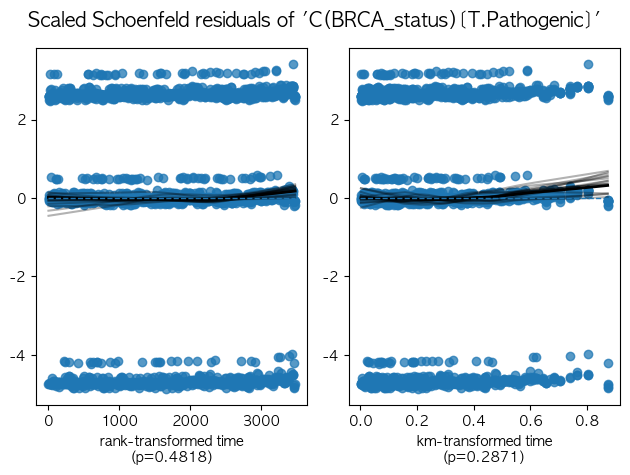

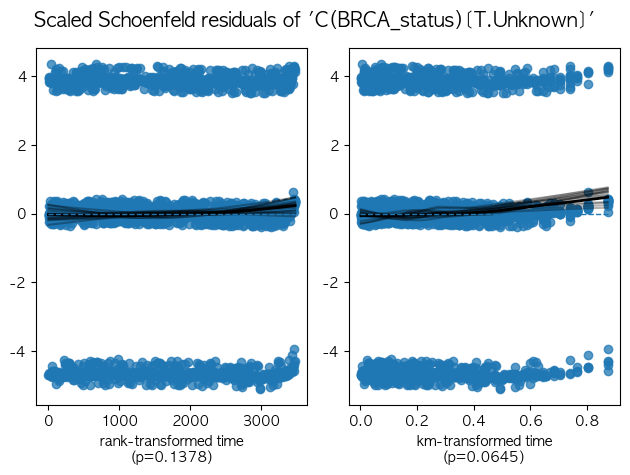

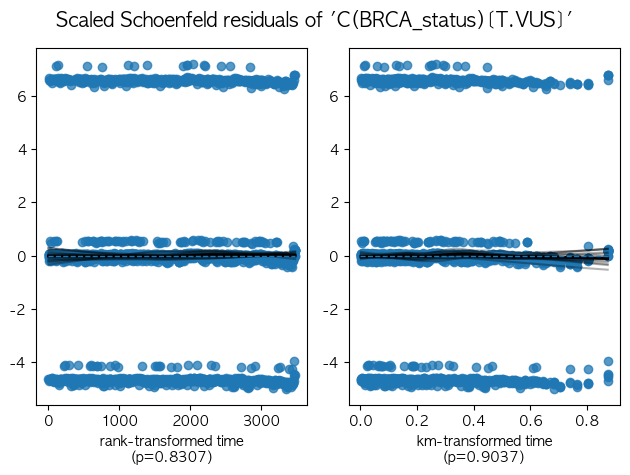

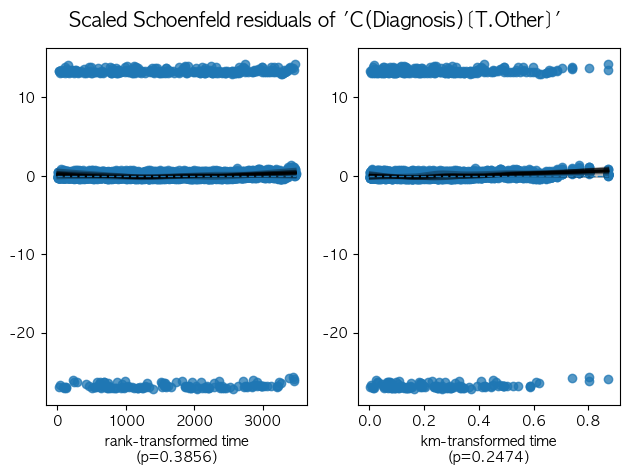

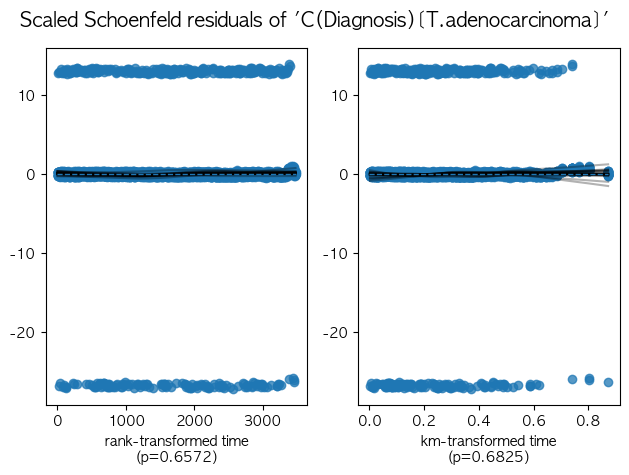

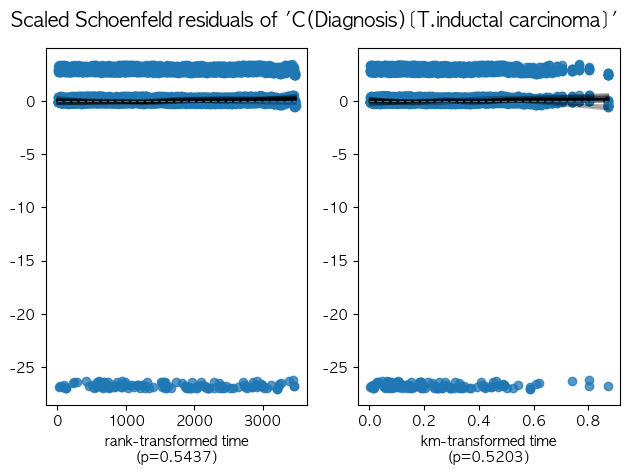

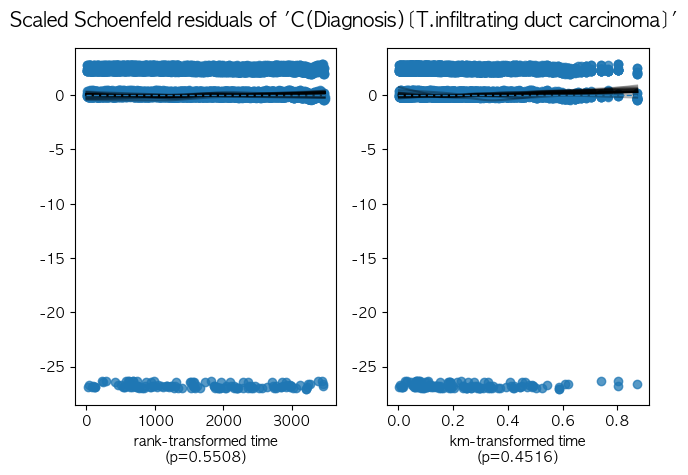

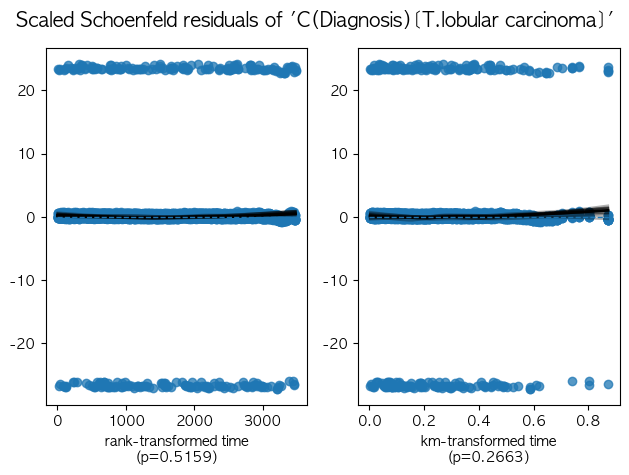

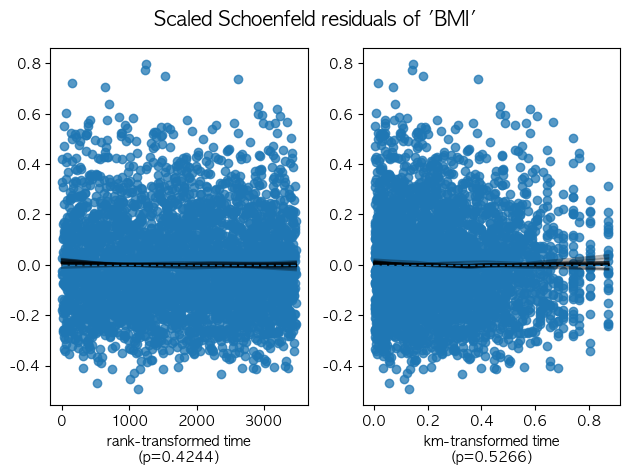

In [49]:
cph_final.check_assumptions(
    df_cox,
    p_value_threshold=0.05,
    show_plots=True
)

In [50]:
ph = cph_final.predict_partial_hazard(df_cox).astype(float)
base_ch = cph_final.baseline_cumulative_hazard_.iloc[:, 0]   
timeline = base_ch.index.values.astype(float)
Hvals = base_ch.values.astype(float)

T = df_cox[time_col].astype(float).values
E = df_cox[event_col].astype(int).values

idx = np.searchsorted(timeline, T, side="right") - 1
idx = np.clip(idx, 0, len(timeline) - 1)
H0_T = Hvals[idx]

mart = E - H0_T * ph.values

eps = 1e-12
term = mart + E * np.log(np.clip(E - mart, eps, None))
dev = np.sign(mart) * np.sqrt(np.clip(-2.0 * term, 0.0, None))

resid = df_cox.copy()
resid["martingale"] = mart
resid["deviance"] = dev

print(resid[["martingale", "deviance"]].describe())

         martingale      deviance
count  1.000000e+04  10000.000000
mean   1.313616e-16     -0.076837
std    5.862093e-01      1.057114
min   -2.171448e+00     -2.083961
25%   -3.500242e-01     -0.822245
50%   -9.888295e-02     -0.431223
75%    5.587349e-01      0.720242
max    9.982703e-01      3.274604


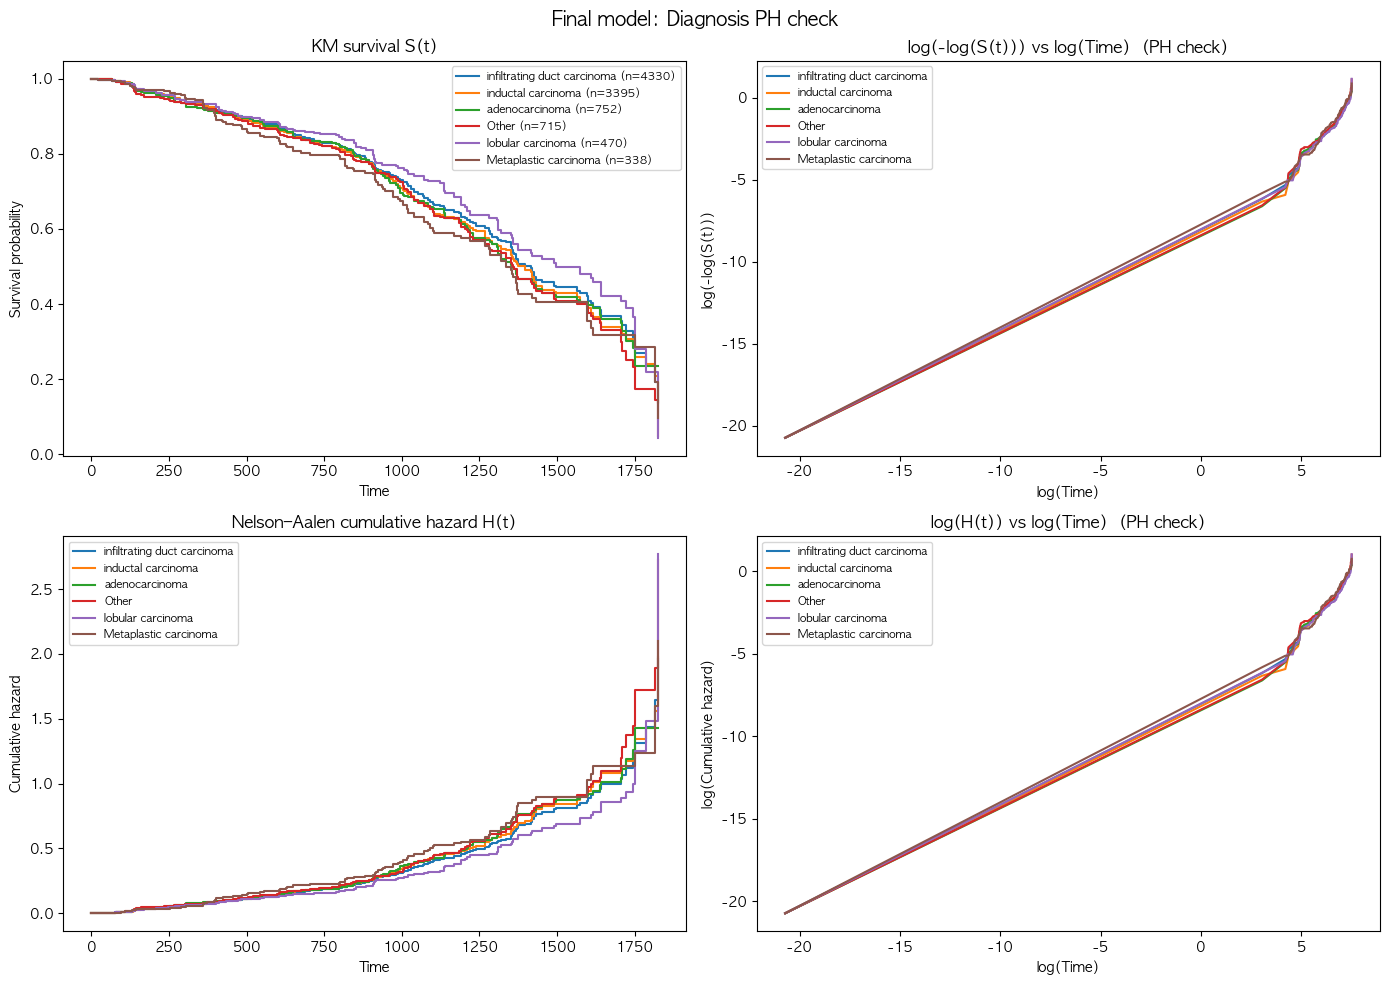


[Diagnosis] counts (min_n=30 applied)
Diagnosis
infiltrating duct carcinoma    4330
inductal carcinoma             3395
adenocarcinoma                  752
Other                           715
lobular carcinoma               470
Metaplastic carcinoma           338
Name: count, dtype: int64


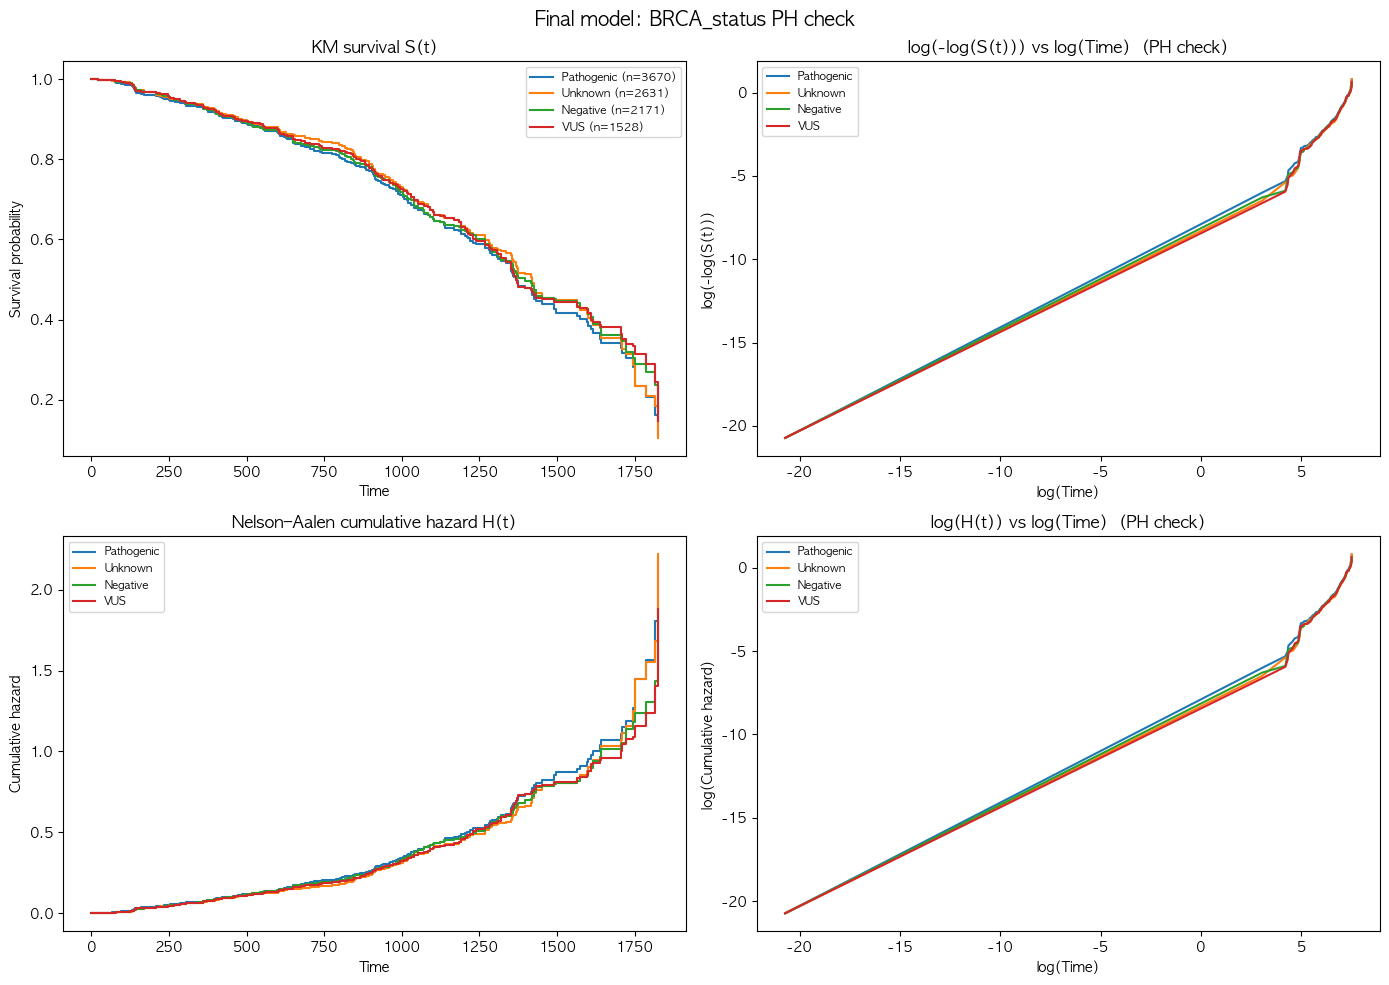


[BRCA_status] counts (min_n=30 applied)
BRCA_status
Pathogenic    3670
Unknown       2631
Negative      2171
VUS           1528
Name: count, dtype: int64


In [51]:
def ph_plots_for_categorical(
    df, group_col,
    time_col="Survival period", event_col="Death",
    min_n=30,
    eps=1e-9,
    title_prefix=None
):

    tmp = df[[time_col, event_col, group_col]].dropna().copy()

    counts = tmp[group_col].value_counts()
    levels = counts[counts >= min_n].index.tolist()

    if len(levels) == 0:
        print(f"[{group_col}] min_n={min_n} 이상 그룹이 없습니다.")
        return

    kmf = KaplanMeierFitter()
    naf = NelsonAalenFitter()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axS, axLL, axH, axlogH = axes[0,0], axes[0,1], axes[1,0], axes[1,1]

    for lv in levels:
        mask = (tmp[group_col] == lv)
        d = tmp.loc[mask, time_col].astype(float)
        e = tmp.loc[mask, event_col].astype(int)

        # 1) KM survival
        kmf.fit(durations=d, event_observed=e, label=str(lv))
        sf = kmf.survival_function_.copy()
        axS.plot(sf.index.values, sf[kmf._label].values, drawstyle="steps-post",
                 label=f"{lv} (n={mask.sum()})")

        # 2) log(-log(S(t))) vs log(t)
        t = sf.index.values
        S = np.clip(sf[kmf._label].values, eps, 1 - eps)
        x = np.log(np.clip(t, eps, None))
        y = np.log(-np.log(S))
        axLL.plot(x, y, label=str(lv))

        # 3) Nelson-Aalen cumulative hazard
        naf.fit(durations=d, event_observed=e, label=str(lv))
        ch = naf.cumulative_hazard_.copy()
        axH.plot(ch.index.values, ch[str(lv)].values, drawstyle="steps-post", label=str(lv))

        # 4) log(H(t)) vs log(t)
        tt = ch.index.values
        H = np.clip(ch[str(lv)].values, eps, None)
        xx = np.log(np.clip(tt, eps, None))
        yy = np.log(H)
        axlogH.plot(xx, yy, label=str(lv))

    main_title = f"{group_col} PH check"
    if title_prefix:
        main_title = f"{title_prefix}: {main_title}"
    fig.suptitle(main_title, fontsize=14)

    axS.set_title("KM survival S(t)")
    axS.set_xlabel("Time")
    axS.set_ylabel("Survival probability")
    axS.legend(fontsize=8)

    axLL.set_title("log(-log(S(t))) vs log(Time)  (PH check)")
    axLL.set_xlabel("log(Time)")
    axLL.set_ylabel("log(-log(S(t)))")
    axLL.legend(fontsize=8)

    axH.set_title("Nelson–Aalen cumulative hazard H(t)")
    axH.set_xlabel("Time")
    axH.set_ylabel("Cumulative hazard")
    axH.legend(fontsize=8)

    axlogH.set_title("log(H(t)) vs log(Time)  (PH check)")
    axlogH.set_xlabel("log(Time)")
    axlogH.set_ylabel("log(Cumulative hazard)")
    axlogH.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    print(f"\n[{group_col}] counts (min_n={min_n} applied)")
    print(counts.loc[levels])

for col in ["Diagnosis", "BRCA_status"]:
    ph_plots_for_categorical(df_cox, col, title_prefix="Final model")